# MASTER THESIS - model of interior temperature

This notebook demonstrates the usage of the `DarkGreyBox` models via fitting them with `DarkGreyFit`

Model used: 
##### TiTmCn2R2C_summer_V9

Period:
##### 01/09 --> 15/09

## Importation

In [1]:
import sys
import importlib
from pathlib import Path
import pvlib
from scipy.interpolate import BSpline

# go from ...\docs\tutorials up two levels to the repo root (...\darkgreybox)
repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root))
importlib.invalidate_caches()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from statsmodels.graphics.tsaplots import plot_pacf

from darkgreybox.models import TiTmCn2R2C_summer_V9
from darkgreybox.night_ventilation import simulate_night_vent_scenario, comfort_metrics
from darkgreybox.fit import darkgreyfit
from docs.tutorials.util.plot import plot
from docs.tutorials.util.error import rmse

C:\Users\clemr\AppData\Roaming\Python\Python311\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


2026-05-10 20:10:53,280 darkgreybox  INFO     Logging enabled...


Our temporal resolution is 5 minutes

In [2]:
# the duration of a record (in h - 5 minutes)
rec_duration = 15/60

## Data Loading and Preprocessing

The data is loaded from the CSV file 'data_summer' and processed to extract relevant variables for the thermal model.

In [3]:
def add_bspline_features(df, n_knots=6, degree=3):
    """Add B-spline basis functions using datetime index."""
    # Extract hour of day from the index (assuming it's datetime)
    hour_of_day = df.index.hour + df.index.minute / 60
    
    # Knots from 6am to 8pm
    knots_interior = np.linspace(6, 20, n_knots)
    knots = np.concatenate([
        [knots_interior[0]] * (degree + 1),
        knots_interior,
        [knots_interior[-1]] * (degree + 1)
    ])
    
    n_basis = len(knots) - degree - 1
    
    for i in range(n_basis):
        coef = np.zeros(n_basis)
        coef[i] = 1.0
        bspline = BSpline(knots, coef, degree)
        df[f'bs_{i}'] = bspline(hour_of_day)
    
    return df, n_basis

In [4]:
input_df = pd.read_csv('./data/monthly_csv_exports/2025-05.csv', index_col=0, parse_dates=True)

input_df['Ti'] = input_df['R01_07_TRU01']
input_df['qv'] = input_df['R01_07_FCI01']
input_df['c'] = input_df['R01_07_CO201']  # Use processed CO2 column
input_df['Ta'] = input_df['HTR9_VES01_TUD01']
input_df['Ik'] = input_df['HTR9_VES01_SI01']
input_df['Tsup'] = input_df['HTRK_VEN01_TI01']
input_df['theta_z'] = input_df['HTR9_VES01_AZ01']
input_df['gamma_s'] = input_df['HTR9_VES01_SV01']
input_df['T_neigh_1'] = input_df['R01_06_TRU01']
input_df['T_neigh_2'] = input_df['R01_08_TRU01']


# Set initial conditions
input_df['Ti0'] = input_df['Ti'].iloc[0]
input_df['Tm0'] = input_df['Ti'].iloc[0]
input_df['c0'] = input_df['c'].iloc[0]
input_df['N0'] = 0 #We suppose no one in the room at the beginning


input_X = input_df[['qv', 'c', 'Ta', 'Ik', 'Tsup', 'theta_z', 'gamma_s', 'Ti0', 'Tm0', 'c0', 'N0', 'T_neigh_1', 'T_neigh_2']]
input_y = input_df['Ti']


print(f'Input X shape: {input_X.shape}, input y shape: {input_y.shape}')

Input X shape: (2976, 13), input y shape: (2976,)


## Data Splitting

Initial conditions are set for the state variables at t=0, using the first measurements from the dataset. The data is then split into training (80%) and test (20%) sets for model validation.
`shuffle=False` to preserve the temporal order of the time series data. This is important for thermal modeling where historical context matters.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(input_X, input_y, test_size=0.2, shuffle=False)

print(f'Train: X shape: {X_train.shape}, y shape: {y_train.shape}')
print(f'Test: X shape: {X_test.shape}, y shape: {y_test.shape}')

# Before training:
X_train, n_bsplines = add_bspline_features(X_train)
X_test, _ = add_bspline_features(X_test)
print(f"Created {n_bsplines} B-spline basis functions")

Train: X shape: (2380, 13), y shape: (2380,)
Test: X shape: (596, 13), y shape: (596,)
Created 10 B-spline basis functions


## Model Training Parameters and Physical Constants

The parameter ranges are carefully chosen to reflect realistic physical bounds and to ensure the optimizer does not hit artificial limits during fitting. Capacitances and resistances are estimated from building material properties and geometry, while internal gains and constants are set according to typical values found in literature or building standards. This approach balances physical realism with flexibility for model calibration.

In [6]:
S_room = 11                             #Surface of the room, found on Revit (m²)
A_windows = 5.48                        #Window area found on Revit (m²)
H_room = 2.7                            #Height of the room (m)
V_room = S_room * H_room                #Volume of the room (m³)
orientation = 270                       # West orientation in degrees

A_neigh_1 = 4*H_room                    # Surface of the neighbor wall 1 (m²) - estimated based on Revit
A_neigh_2 = 4*H_room                    # Surface of the neighbor wall 2 (m²) - estimated based on Revit
U_interior_wall = 1.8                   # U-value of interior walls (W/m²K) - single gypsum board + metal stud 

Rneih_1_i = 1/(U_interior_wall*A_neigh_1)
Rneih_2_i = 1/(U_interior_wall*A_neigh_2)


# Capacitances initial guesses
# C=ρ×V×c_p [J/K] (ρ density kg/m³, V volume m³, c_p specific heat capacity J/kgK)
rho_air_init = 1.2          # kg/m³
cp_air_init = 1005          # J/kgK
rho_furn_init = 500         # kg/m³
cp_furn_init = 1200         # J/kgK
V_furn_init = 0.1 * V_room  # m³  (10% of room volume as furniture/contents volume)
Ci_i = rho_air_init * V_room * cp_air_init + rho_furn_init * V_furn_init * cp_furn_init

rho_wall = 2200             # kg/m³
cp_conc  = 840              # J/kgK
wall_thickness = 0.1        # m
Cm_i = rho_wall * (S_room * wall_thickness) * cp_conc  



# Resistances initial guesses
# R=1/(U*A) or 1/(h*A) [K/W]
h_conv = 8                     # W/m²K
S_int_mass = 0.6 * S_room      # internal surfaces area ~60%
Rim_i = 1 / (h_conv * S_int_mass)

U_env = 0.25                   # W/m²K
Rout_i= 1 / (U_env * S_room)


# Capacitances and resistances variation ranges
# WIDENED based on optimizer hitting bounds (see diagnostic cell)
Ci_min = 0.05*Ci_i      # Was 0.2x → lowered (optimizer wanted smaller)
Ci_max = 2*Ci_i         # Keep similar
Cm_min = 0.1*Cm_i       # Was 0.5x → lowered (optimizer wanted smaller)
Cm_max = 3*Cm_i         # Keep similar

Rim_min = 0.2*Rim_i     # Slightly lower
Rim_max = 2*Rim_i       # Keep similar
Rout_min = 0.1*Rout_i   # Was 0.5x → lowered (optimizer wanted more heat loss)
Rout_max = 2*Rout_i     # Keep similar



# Define training parameters
train_params_TiTmCn2R2C_summer_V4 = {
    'Ti0': {'value': input_df.iloc[0]['Ti0'], 'vary': False},               # Initial indoor temperature
    'Tm0': {'value': input_df.iloc[0]['Tm0'], 'vary': False},               # Initial thermal mass temperature
    'c0': {'value': input_df.iloc[0]['c0'], 'vary': False},                 # Initial CO2 concentration
    'N0': {'value': input_df.iloc[0]['N0'], 'vary': False},                 # Initial number of occupants
    
    #'Ci': {'value': Ci_i, 'vary': True, 'min': Ci_min, 'max': Ci_max},      # Air + light internal components heat capacity at air node (fast mass at Ti)
    #'Cm': {'value': Cm_i, 'vary': True, 'min': Cm_min, 'max': Cm_max},      # Thermal mass heat capacity (heavy structural mass at Tm)
    #'Rim': {'value': Rim_i, 'vary': True, 'min': Rim_min, 'max': Rim_max},  # Thermal resistance indoor air ↔ thermal mass (heat air ↔ building structure)
    #'Rout': {'value': Rout_i, 'vary': True, 'min': Rout_min, 'max': Rout_max},  # Overall thermal resistance indoor air ↔ ambient/outdoor air (heat loss path)
    'Ci': {'value': 1000.19534, 'vary': True, 'min': 1000, 'max': 10000},
    'Cm': {'value': 4167.99849, 'vary': True, 'min': 1000, 'max': 50000},    # Bigger mass\n",
    'Rim': {'value': 0.00153473, 'vary': True, 'min': 0.001, 'max': 0.01},           # Mass-air  \n",
    'Rout': {'value': 0.08885421, 'vary': True, 'min': 0.01, 'max': 1},         # Envelope\n",
    'q_pers': {'value': 75, 'vary': False},                                 # Internal gains per person
    'q_equip_var': {'value': 80, 'vary': False},                            # Variable equipment gains per person
    'q_equip_const': {'value': 10, 'vary': False},                          # Constant equipment gains
    'V': {'value': S_room*H_room, 'vary': False},                           # Volume of the room
    'S': {'value': S_room, 'vary': False},                                  # Surface of the room
    'A': {'value': A_windows, 'vary': False},                               # Window area
    'G': {'value': 0.016, 'vary': False},                                   # Global radiation factor
    'c_out': {'value': 400, 'vary': False},                                 # Outdoor CO2 concentration
    'rho_air': {'value': 1.2, 'vary': False},                               # Air density
    'cp_air': {'value': 1000, 'vary': False},                               # Specific heat capacity of air
    #'g': {'value': 0.55, 'vary': False},                                    # total solar energy transmittance of the glazing 
    'alpha': {'value': 0.1, 'vary': True, 'min': 0.01, 'max': 0.5},         # CO2 occupancy filter parameter
    'gamma_g': {'value': orientation, 'vary': False},                    # glazing angle for IAM calculation
    'n': {'value': 1.526, 'vary': False},                                        # refractive index for IAM calculation
    'K': {'value': 4, 'vary': False},                                   # absorption coefficient for IAM calculation (1/m)
    'L': {'value': 0.003, 'vary': False},                                     # glazing thickness for IAM calculation (m)
    'Rneigh_1': {'value': Rneih_1_i, 'vary': True, 'min': Rneih_1_i*0.1, 'max': Rneih_1_i*10},         # Thermal resistance between the room and the neighboring spaces (simplified representation of heat transfer through internal walls)
    'Rneigh_2': {'value': Rneih_2_i, 'vary': True, 'min': Rneih_2_i*0.1, 'max': Rneih_2_i*10},         # Thermal resistance between the room and the neighboring spaces (simplified representation of heat transfer through internal walls)
    'f_sol': {'value': 0.4, 'vary': True, 'min': 0, 'max': 1},         # Solar gains distribution factor (fraction of solar gains directly affecting indoor air node)
    # 10 B-spline coefficients
    'phi_a': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_b': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_c': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_d': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_e': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_f': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_g': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},  
    'phi_h': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_i': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
    'phi_j': {'value': 0.7, 'vary': True, 'min': 0, 'max': 1},
}

# Verify stability
print(f"dt = {rec_duration:.4f} hours ({rec_duration * 60:.2f} minutes)")

dt = 0.2500 hours (15.00 minutes)


### 1: Initial conditions
Set up our initial conditions parameters map for testing

### 2: Error metric
To evaluate the performance of our models we will need to define an error metric. Again, there is a wide range of options available from `sklearn`

### 3: Fit method
Under the hood, `DarkGreyBox` uses `lmfit.minimize` to fit the thermal model parameters to the training data by passing it a custom objective function defined by the model class. The fit method used by `lmfit.minimize` can be customised as well. The standard Nelder-Mead and Levenberg-Marquardt methods work well in general. Here we use the Nelder-Mead method.

### 4: Choice of the model

In [7]:
ic_params_map = {
    'Ti0': lambda _X_test, y_test, _train_result: y_test.iloc[0],
    'Tm0': lambda X_test, _y_test, train_result: train_result.var['Tm'][-1] if 'Tm' in train_result.var else X_test.iloc[0]['Tm0'],
    'c0': lambda X_test, _y_test, train_result: train_result.var['c'][-1] if 'c' in train_result.var else X_test.iloc[0]['c0'],
    'N0': lambda X_test, _y_test, train_result: train_result.var['N'][-1] if 'N' in train_result.var else X_test.iloc[0]['N0'],
}

error_metric = rmse

method = 'nelder'

models = [TiTmCn2R2C_summer_V9(train_params_TiTmCn2R2C_summer_V4, rec_duration)]

Now, it is time to run the simulation:

In [8]:
# Run the darkgreyfit
df = darkgreyfit(
    models=models,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    ic_params_map=ic_params_map,
    error_metric=error_metric,
    prefit_filter=None,
    prefit_splits=None,
    method=method,
    n_jobs=1
)

print("Fitting complete!")
print(f"DataFrame shape: {df.shape}")

df

model = df.iloc[0][('train', 'model')]
train_results = df.iloc[0][('train', 'model_result')]
test_results = df.iloc[0][('test', 'model_result')]

# Display model parameters safely
if hasattr(model, "result") and hasattr(model.result, "params"):
    display(model.result.params)
else:
    print("Model parameters not available.")

# Print initial, real initial guess (used in fit), and estimated R and C values
# Initial parameter guesses (from physical calculations)
try:
    init_params = {
        'Ci': {'value': Ci_i},
        'Cm': {'value': Cm_i},
        'Rim': {'value': Rim_i},
        'Rout': {'value': Rout_i}
    }
except NameError:
    # If any of the variables are not defined, set to None
    init_params = {
        'Ci': {'value': None},
        'Cm': {'value': None},
        'Rim': {'value': None},
        'Rout': {'value': None}
    }

# Real initial guess used in fit (from train_params_TiTmCn2R2C_summer)
real_init_params = {}
for key in ['Ci', 'Cm', 'Rim', 'Rout']:
    try:
        real_init_params[key] = train_params_TiTmCn2R2C_summer_V4[key]['value']
    except Exception:
        real_init_params[key] = None

if hasattr(model, "result") and hasattr(model.result, "params"):
    est_params = model.result.params
    print("Parameter   | Initial Guess (calc) | Real Initial Guess (used) | Estimated Value")
    print("--------------------------------------------------------------------------")
    for key in ['Ci', 'Cm', 'Rim', 'Rout']:
        init_val = init_params[key]['value']
        real_init_val = real_init_params[key]
        est_val = est_params[key].value if key in est_params else None
        if init_val is not None and real_init_val is not None and est_val is not None:
            print(f"{key:10} | {init_val:18.4f} | {real_init_val:23.4f} | {est_val:15.4f}")
        elif init_val is not None and real_init_val is not None:
            print(f"{key:10} | {init_val:18.4f} | {real_init_val:23.4f} | {'N/A':>15}")
        elif real_init_val is not None and est_val is not None:
            print(f"{key:10} | {'N/A':>18} | {real_init_val:23.4f} | {est_val:15.4f}")
        elif init_val is not None and est_val is not None:
            print(f"{key:10} | {init_val:18.4f} | {'N/A':>23} | {est_val:15.4f}")
        else:
            print(f"{key:10} | {'N/A':>18} | {'N/A':>23} | {'N/A':>15}")
else:
    print("Model parameters not available for comparison.")

2026-05-10 20:10:54,149 darkgreybox  INFO     Training models...
2026-05-10 20:18:41,366 darkgreybox  INFO     Generating predictions for 1 models...
Fitting complete!
DataFrame shape: (1, 13)


name,value,initial value,min,max,vary
Ti0,23.9000000,24.3,-inf,inf,False
Tm0,23.7217009,24.3,-inf,inf,False
c0,424.780960,422.7701697,-inf,inf,False
N0,4.5141e-44,0.0,-inf,inf,False
Ci,1000.00757,1000.19534,1000.00000,10000.0000,True
Cm,1003.15754,4167.99849,1000.00000,50000.0000,True
Rim,0.00406458,0.00153473,1.0000e-03,0.01000000,True
Rout,0.06893895,0.08885421,0.01000000,1.00000000,True
q_pers,75.0000000,75.0,-inf,inf,False
q_equip_var,80.0000000,80.0,-inf,inf,False


Parameter   | Initial Guess (calc) | Real Initial Guess (used) | Estimated Value
--------------------------------------------------------------------------
Ci         |       1817818.2000 |               1000.1953 |       1000.0076
Cm         |       2032800.0000 |               4167.9985 |       1003.1575
Rim        |             0.0189 |                  0.0015 |          0.0041
Rout       |             0.3636 |                  0.0889 |          0.0689


# emcee approach for MCMC

Step 1 - Wrap your model as a callable

In [9]:
import emcee
import numpy as np

PARAM_NAMES = ['Ci', 'Cm', 'Rim', 'Rout', 'alpha',
               'Rneigh_1', 'Rneigh_2', 'f_sol',
               'phi_a', 'phi_b', 'phi_c', 'phi_d', 'phi_e',
               'phi_f', 'phi_g', 'phi_h', 'phi_i', 'phi_j']

BOUNDS = {
    'Ci':       (100,    10000),   # ← CHANGED: was (1000, 10000), Ci was hitting lower bound
    'Cm':       (1000,   50000),
    'Rim':      (0.001,  0.01),
    'Rout':     (0.01,   1.0),
    'alpha':    (0.01,   0.5),
    'Rneigh_1': (Rneih_1_i*0.1, Rneih_1_i*10),
    'Rneigh_2': (Rneih_2_i*0.1, Rneih_2_i*10),
    'f_sol':    (0.0,    1.0),
    **{f'phi_{c}': (0.0, 1.0) for c in 'abcdefghij'}
}

Step 2 — Log-prior, log-likelihood, log-posterior

In [10]:
def log_prior(theta):
    for val, name in zip(theta, PARAM_NAMES):
        lo, hi = BOUNDS[name]
        if not (lo <= val <= hi):
            return -np.inf           # hard wall at physical bounds
    return 0.0                       # uniform prior within bounds
    # For Gaussian priors, replace with:
    # return -0.5 * ((val - mu) / sigma_prior)**2


def _as_lmfit_params(params_template):
    """Accept lmfit.Parameters OR the original train-params dict."""
    import copy
    import lmfit

    if isinstance(params_template, lmfit.Parameters):
        return copy.deepcopy(params_template)

    if isinstance(params_template, dict):
        p = lmfit.Parameters()
        for k, v in params_template.items():
            if not isinstance(v, dict):
                raise TypeError(f"Parameter '{k}' must be a dict, got {type(v)}")
            p.add(k, **v)
        return p

    raise TypeError(
        f"params_template must be lmfit.Parameters or dict, got {type(params_template)}"
    )


def run_model_with_theta(theta, X, params_template):
    """Inject MCMC theta vector into params and run forward model."""
    params = _as_lmfit_params(params_template)

    for name, val in zip(PARAM_NAMES, theta):
        params[name].value = float(val)

    model_instance = TiTmCn2R2C_summer_V9(params, rec_duration)
    result = model_instance.model(params, X)
    return np.asarray(result.Z, dtype=float)   # Ti prediction array


def log_likelihood(theta, X_dict, y_obs, params_template):
    Ti_pred = run_model_with_theta(theta, X_dict, params_template)

    if np.any(np.isnan(Ti_pred)) or np.any(np.isinf(Ti_pred)):
        return -np.inf
    if Ti_pred.shape[0] != len(y_obs):
        return -np.inf

    # Estimate noise sigma from residuals (or treat as free param)
    sigma = 0.3  # degC — tune or sample this too
    residuals = np.asarray(y_obs, dtype=float) - Ti_pred
    return -0.5 * np.sum((residuals / sigma)**2 + np.log(2 * np.pi * sigma**2))


def log_posterior(theta, X_dict, y_obs, params_template):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, X_dict, y_obs, params_template)

Step 3 — Initialize walkers from Nelder-Mead solution

In [11]:
# Warm-start: use your fitted Nelder-Mead result as the center
theta_map = np.array([model.result.params[n].value for n in PARAM_NAMES])

ndim     = len(PARAM_NAMES)
nwalkers = max(4 * ndim, 64)   # rule-of-thumb: ≥ 2*ndim, 4x is safer

# Small Gaussian ball around the MAP estimate   
rng = np.random.default_rng(42)
p0 = theta_map + 1e-2 * rng.standard_normal((nwalkers, ndim)) * theta_map

# Convert X_train to dict of arrays (emcee needs picklable args)
X_dict = {col: X_train[col].values for col in X_train.columns}
y_obs  = y_train.values

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior,
    args=(X_dict, y_obs, train_params_TiTmCn2R2C_summer_V4),
    moves=[emcee.moves.DEMove(), emcee.moves.DESnookerMove()],  # better for correlated params
)

Step 4 — Run burn-in + production

In [12]:
# Burn-in phase
print("Running burn-in...")
state = sampler.run_mcmc(p0, nsteps=500, progress=True)
sampler.reset()

# Production run
print("Running production...")
sampler.run_mcmc(state, nsteps=2000, progress=True)

# Extract flat samples
flat_samples = sampler.get_chain(discard=200, thin=15, flat=True)
print(f"Posterior samples shape: {flat_samples.shape}")

# ── NEW: acceptance fraction check ──────────────────────────────────────
acc = np.mean(sampler.acceptance_fraction)
print(f"\nMean acceptance fraction: {acc:.3f}")
if acc < 0.1:
    print("  ⚠ Too low (<0.1) — walkers are stuck. Consider fewer nsteps or wider bounds.")
elif acc > 0.7:
    print("  ⚠ Too high (>0.7) — walkers barely moving. Proposals may be too small.")
else:
    print("  ✓ Acceptance fraction looks healthy (target: 0.2–0.5)")

# ── NEW: autocorrelation time check ─────────────────────────────────────
try:
    tau = sampler.get_autocorr_time(quiet=True)
    print(f"\nAutocorrelation times (need nsteps > 50×tau):")
    for name, t in zip(PARAM_NAMES, tau):
        flag = "⚠ need more steps" if 2000 < 50 * t else "✓"
        print(f"  {name:12s}: tau={t:.1f}  (50×tau={50*t:.0f})  {flag}")
except Exception as e:
    print(f"Autocorr could not be computed yet: {e}")

# ── NEW: print median ± uncertainty for every parameter ─────────────────
print(f"\nParameter estimates (median +84th / -16th percentile):")
for i, name in enumerate(PARAM_NAMES):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"  {name:12s}: {mcmc[1]:.5f}  +{q[1]:.5f} / -{q[0]:.5f}")

Running burn-in...


  0%|          | 0/500 [00:00<?, ?it/s]c:\Users\clemr\AppData\Local\Programs\Python\Python311\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 500/500 [04:00<00:00,  2.08it/s]


Running production...


100%|██████████| 2000/2000 [07:00<00:00,  4.75it/s]


Posterior samples shape: (8640, 18)

Mean acceptance fraction: 0.021
  ⚠ Too low (<0.1) — walkers are stuck. Consider fewer nsteps or wider bounds.
2026-05-10 20:29:43,497 emcee.autocorr WARNING  The chain is shorter than 50 times the integrated autocorrelation time for 18 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [182.4360493  183.18692289 190.98903716 203.20209875 201.04112394
 188.46611155 179.00997117 205.74359375 176.79083929 186.03993769
 193.36896208 195.93797696 183.22461721 173.43518752 182.79518086
 186.60531474 219.60653543 175.15138538]

Autocorrelation times (need nsteps > 50×tau):
  Ci          : tau=182.4  (50×tau=9122)  ⚠ need more steps
  Cm          : tau=183.2  (50×tau=9159)  ⚠ need more steps
  Rim         : tau=191.0  (50×tau=9549)  ⚠ need more steps
  Rout        : tau=203.2  (50×tau=10160)  ⚠ need more steps
  alpha       : tau=201.0  (50×tau=10052)  ⚠ need more steps
  Rneigh_1    : tau=188.5  (50×tau=9423)  ⚠ need more

Step 5 — Analyze posteriors

2026-05-10 20:29:43,595 arviz.preview INFO     arviz_base not installed
2026-05-10 20:29:43,599 arviz.preview INFO     arviz_stats not installed
2026-05-10 20:29:43,601 arviz.preview INFO     arviz_plots not installed
2026-05-10 20:29:53,521 root         WARNING  Too few points to create valid contours
2026-05-10 20:29:55,992 root         WARNING  Too few points to create valid contours
2026-05-10 20:29:56,024 root         WARNING  Too few points to create valid contours


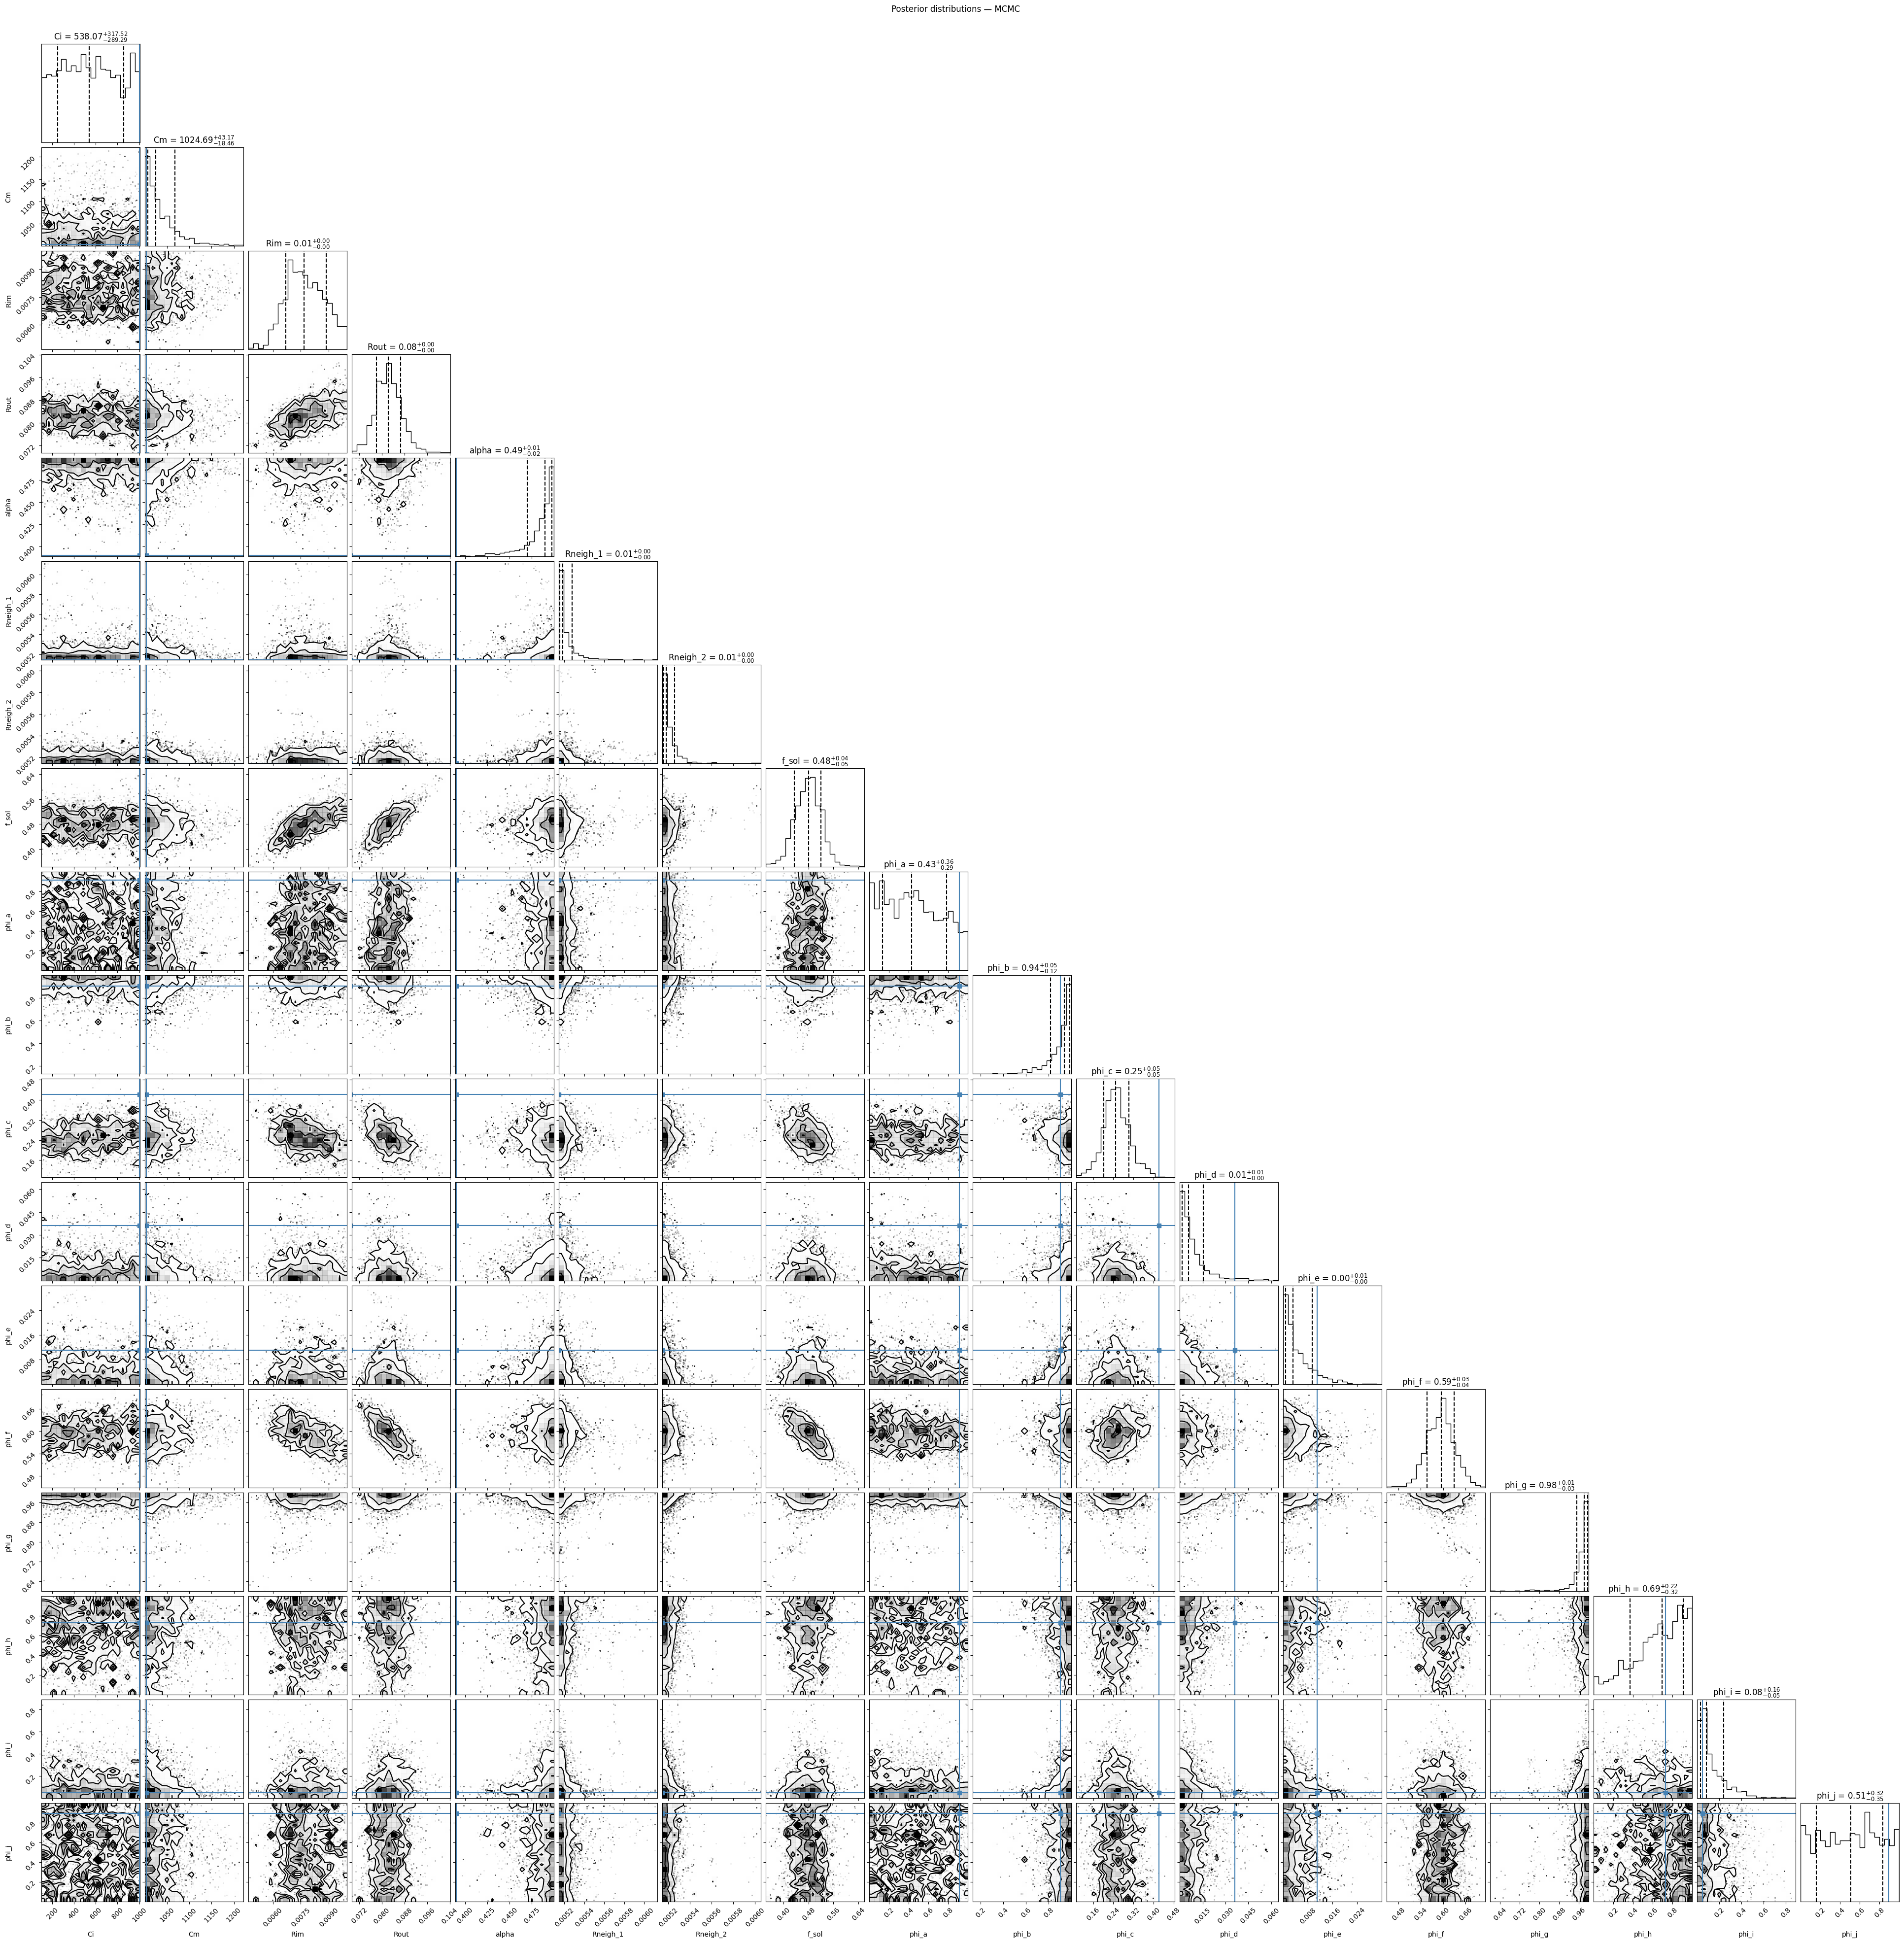

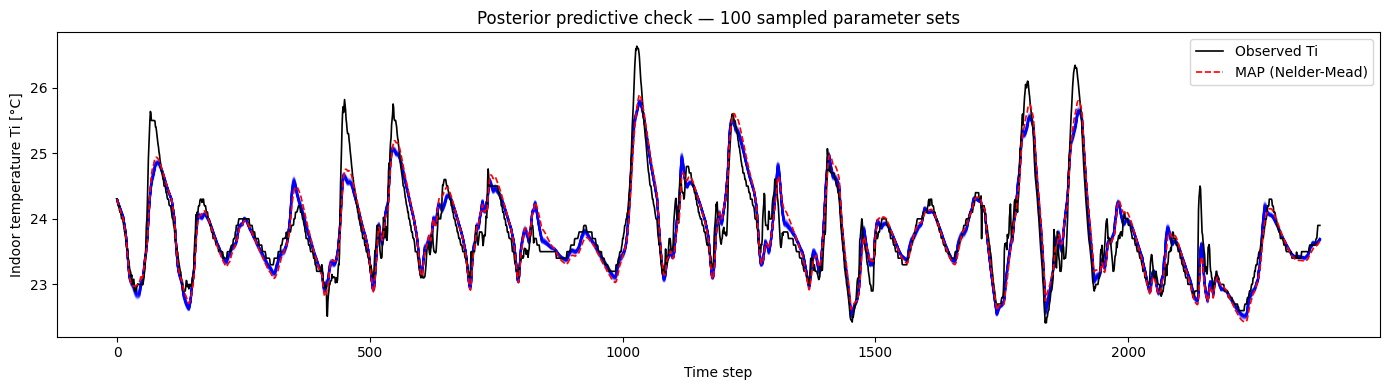

In [13]:
import matplotlib.pyplot as plt
import corner

# ── Corner plot ──────────────────────────────────────────────────────────
fig = corner.corner(
    flat_samples,
    labels=PARAM_NAMES,
    truths=theta_map,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True
)
fig.suptitle("Posterior distributions — MCMC", y=1.01)
plt.show()

# ── Posterior predictive check ───────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(14, 4))                # ← NEW: explicit figure

rng_plot = np.random.default_rng(0)
for i in range(100):
    idx     = rng_plot.integers(len(flat_samples))
    theta_s = flat_samples[idx]
    Ti_pred = run_model_with_theta(theta_s, X_dict, train_params_TiTmCn2R2C_summer_V4)
    ax.plot(Ti_pred, alpha=0.05, color='blue')

ax.plot(y_obs, 'k-', linewidth=1.2, label='Observed Ti')
ax.plot(                                                 # ← NEW: MAP prediction in red
    run_model_with_theta(theta_map, X_dict, train_params_TiTmCn2R2C_summer_V4),
    'r--', linewidth=1.2, label='MAP (Nelder-Mead)'
)
ax.set_xlabel("Time step")
ax.set_ylabel("Indoor temperature Ti [°C]")
ax.set_title("Posterior predictive check — 100 sampled parameter sets")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
from sklearn.metrics import mean_squared_error

# ── Helper: run model with proper IC handoff train→test ──────────────────
def run_model_with_theta_and_ic(theta, X_dict_train, X_dict_test, y_train_arr, params_template):
    """
    Step 1: run on training set → extract final states (Tm, c, N)
    Step 2: set test ICs from those final states + y_test[0] for Ti0
    Step 3: run on test set
    """
    import copy, lmfit

    def make_params(extra_ic=None):
        params = _as_lmfit_params(params_template)
        for name, val in zip(PARAM_NAMES, theta):
            params[name].value = float(val)
        if extra_ic:
            for k, v in extra_ic.items():
                params[k].value = float(v)
        return params

    # Step 1 — training run to get final states
    p_train = make_params()
    m_train = TiTmCn2R2C_summer_V9(p_train, rec_duration)
    r_train = m_train.model(p_train, X_dict_train)
    Ti_train = np.asarray(r_train.Z, dtype=float)

    # Step 2 — build test initial conditions
    test_ic = {
        'Ti0': y_train_arr[-1],                         # last observed Ti in train
        'Tm0': r_train.var['Tm'][-1] if 'Tm' in r_train.var else y_train_arr[-1],
        'c0':  r_train.var['c'][-1]  if 'c'  in r_train.var else params_template['c0']['value'],
        'N0':  r_train.var['N'][-1]  if 'N'  in r_train.var else 0.0,
    }

    # Step 3 — test run with correct ICs
    p_test = make_params(extra_ic=test_ic)
    m_test = TiTmCn2R2C_summer_V9(p_test, rec_duration)
    r_test = m_test.model(p_test, X_dict_test)
    Ti_test = np.asarray(r_test.Z, dtype=float)

    return Ti_train, Ti_test


# ── 1. Parameter summary table ───────────────────────────────────────────
rows = []
for i, name in enumerate(PARAM_NAMES):
    lo, hi = BOUNDS[name]
    p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    map_val = theta_map[i]
    hitting_lower = abs(p16 - lo) / max(hi - lo, 1e-10) < 0.02
    hitting_upper = abs(p84 - hi) / max(hi - lo, 1e-10) < 0.02
    flag = "⚠ lower bound" if hitting_lower else ("⚠ upper bound" if hitting_upper else "✓")
    rows.append({
        'Parameter':    name,
        'MAP (Nelder)': round(map_val, 6),
        'MCMC median':  round(p50, 6),
        '-1σ (16th)':   round(p50 - p16, 6),
        '+1σ (84th)':   round(p84 - p50, 6),
        'Bound [lo, hi]': f"[{lo:.4g}, {hi:.4g}]",
        'Status': flag
    })

param_df = pd.DataFrame(rows)
display(param_df)

# ── 2. RMSE comparison with correct IC handoff ───────────────────────────
theta_mcmc_median = np.array([np.percentile(flat_samples[:, i], 50) for i in range(ndim)])

X_dict_test = {col: X_test[col].values for col in X_test.columns}
y_obs_test  = y_test.values

# MAP
Ti_map_train, Ti_map_test = run_model_with_theta_and_ic(
    theta_map, X_dict, X_dict_test, y_obs, train_params_TiTmCn2R2C_summer_V4)

# MCMC median
Ti_mcmc_train, Ti_mcmc_test = run_model_with_theta_and_ic(
    theta_mcmc_median, X_dict, X_dict_test, y_obs, train_params_TiTmCn2R2C_summer_V4)

rmse = lambda y, yhat: np.sqrt(mean_squared_error(y, yhat))

print("── RMSE ─────────────────────────────────────────────")
print(f"  {'':20s}  {'Train':>10}  {'Test':>10}")
print(f"  {'MAP (Nelder-Mead)':20s}  {rmse(y_obs, Ti_map_train):>10.4f}  {rmse(y_obs_test, Ti_map_test):>10.4f}")
print(f"  {'MCMC median':20s}  {rmse(y_obs, Ti_mcmc_train):>10.4f}  {rmse(y_obs_test, Ti_mcmc_test):>10.4f}")

# ── 3. Posterior predictive band — FIXED coverage formula ────────────────
sigma_obs = 0.3   # °C — your likelihood noise assumption

n_samples = 300
idx_s = np.random.default_rng(1).integers(len(flat_samples), size=n_samples)

Ti_ensemble = np.stack([
    run_model_with_theta_and_ic(
        flat_samples[i], X_dict, X_dict_test, y_obs, train_params_TiTmCn2R2C_summer_V4
    )[0]   # [0] = train prediction
    for i in idx_s
])

band_mean = Ti_ensemble.mean(axis=0)
band_std  = Ti_ensemble.std(axis=0)   # parametric uncertainty only

# Full predictive std = parametric uncertainty + observation noise
pred_std  = np.sqrt(band_std**2 + sigma_obs**2)

coverage = np.mean(
    (y_obs >= band_mean - 2*pred_std) & (y_obs <= band_mean + 2*pred_std)
) * 100

print(f"\n── Posterior predictive band (train) ─────────────────")
print(f"  Parametric std (band):  {band_std.mean():.4f} °C  ← uncertainty from parameters alone")
print(f"  Observation noise σ:    {sigma_obs:.4f} °C  ← assumed in likelihood")
print(f"  Total prediction std:   {pred_std.mean():.4f} °C  ← sqrt(param² + noise²)")
print(f"  Coverage within ±2σ:    {coverage:.1f}%")
print(f"  (ideal: ~95% — if low, increase sigma_obs; if >99%, decrease it)")

,Parameter,MAP (Nelder),MCMC median,-1σ (16th),+1σ (84th),"Bound [lo, hi]",Status
0,Ci,1000.007575,538.066536,289.292047,317.518012,"[100, 1e+04]",⚠ lower bound
1,Cm,1003.157542,1024.688091,18.456485,43.169887,"[1000, 5e+04]",⚠ lower bound
2,Rim,0.004065,0.007672,0.000973,0.001211,"[0.001, 0.01]",✓
3,Rout,0.068939,0.082306,0.004163,0.004380,"[0.01, 1]",✓
4,alpha,0.390276,0.489958,0.019836,0.007828,"[0.01, 0.5]",⚠ upper bound
5,Rneigh_1,0.005144,0.005182,0.000029,0.000096,"[0.005144, 0.5144]",⚠ lower bound
6,Rneigh_2,0.005145,0.005181,0.000029,0.000075,"[0.005144, 0.5144]",⚠ lower bound
7,f_sol,0.177414,0.479977,0.045818,0.040299,"[0, 1]",✓
8,phi_a,0.914080,0.429369,0.294897,0.355740,"[0, 1]",✓
9,phi_b,0.904639,0.939393,0.124052,0.047232,"[0, 1]",⚠ upper bound


── RMSE ─────────────────────────────────────────────
                             Train        Test
  MAP (Nelder-Mead)         0.2759      0.2131
  MCMC median               0.2631      0.2031

── Posterior predictive band (train) ─────────────────
  Parametric std (band):  0.0179 °C  ← uncertainty from parameters alone
  Observation noise σ:    0.3000 °C  ← assumed in likelihood
  Total prediction std:   0.3006 °C  ← sqrt(param² + noise²)
  Coverage within ±2σ:    95.9%
  (ideal: ~95% — if low, increase sigma_obs; if >99%, decrease it)


### Re-run with the new MCMC parameters

In [15]:
import copy

# ── Wrapper that holds everything plot() might need ──────────────────────
class MockResult:
    def __init__(self, Z, var=None):
        self.Z   = Z
        self.var = var if var is not None else {}

# ── Updated helper: returns full result objects, not just Ti arrays ──────
def run_model_with_theta_and_ic_full(theta, X_dict_train, X_dict_test, y_train_arr, params_template):
    def make_params(extra_ic=None):
        params = _as_lmfit_params(params_template)
        for name, val in zip(PARAM_NAMES, theta):
            params[name].value = float(val)
        if extra_ic:
            for k, v in extra_ic.items():
                params[k].value = float(v)
        return params

    # Step 1 — training run
    p_train  = make_params()
    m_train  = TiTmCn2R2C_summer_V9(p_train, rec_duration)
    r_train  = m_train.model(p_train, X_dict_train)

    # Step 2 — test ICs from end of training run
    test_ic = {
        'Ti0': y_train_arr[-1],
        'Tm0': r_train.var['Tm'][-1] if 'Tm' in r_train.var else y_train_arr[-1],
        'c0':  r_train.var['c'][-1]  if 'c'  in r_train.var else params_template['c0']['value'],
        'N0':  r_train.var['N'][-1]  if 'N'  in r_train.var else 0.0,
    }

    # Step 3 — test run
    p_test = make_params(extra_ic=test_ic)
    m_test = TiTmCn2R2C_summer_V9(p_test, rec_duration)
    r_test = m_test.model(p_test, X_dict_test)

    # Wrap both into MockResult so .Z and .var work downstream
    train_mock = MockResult(np.asarray(r_train.Z, dtype=float), r_train.var)
    test_mock  = MockResult(np.asarray(r_test.Z,  dtype=float), r_test.var)

    return train_mock, test_mock


# ── 1. Extract MCMC median parameter vector ──────────────────────────────
theta_mcmc_median = np.array([np.percentile(flat_samples[:, i], 50) for i in range(ndim)])

# ── 2. Run forward model ─────────────────────────────────────────────────
X_dict_test = {col: X_test[col].values for col in X_test.columns}

train_results, test_results = run_model_with_theta_and_ic_full(
    theta_mcmc_median,
    X_dict, X_dict_test,
    y_train.values,
    train_params_TiTmCn2R2C_summer_V4
)
# y_train and y_test are observed data — they never change

print("── RMSE after MCMC parameter update ─────────────────────")
print(f"  Train RMSE: {rmse(y_train.values, train_results.Z):.4f} °C")
print(f"  Test  RMSE: {rmse(y_test.values,  test_results.Z):.4f} °C")

# ── 3. Convergence diagnostics ───────────────────────────────────────────
try:
    tau = sampler.get_autocorr_time(quiet=True)
    ess = (2000 / tau).astype(int)
    print("\n── Convergence diagnostics ───────────────────────────────")
    print(f"  {'Parameter':12s}  {'tau':>8}  {'ESS':>8}  {'Status'}")
    print(f"  {'-'*50}")
    for name, t, e in zip(PARAM_NAMES, tau, ess):
        flag = "⚠ need more steps" if 2000 < 50 * t else "✓"
        print(f"  {name:12s}  {t:>8.1f}  {e:>8d}  {flag}")
except Exception as ex:
    print(f"Autocorr could not be computed: {ex}")

acc = np.mean(sampler.acceptance_fraction)
print(f"\n  Mean acceptance fraction: {acc:.3f}")
if acc < 0.1:
    print("  ⚠ Too low — walkers stuck. Widen bounds or increase nsteps.")
elif acc > 0.7:
    print("  ⚠ Too high — walkers barely moving.")
else:
    print("  ✓ Healthy (target: 0.2–0.5)")

── RMSE after MCMC parameter update ─────────────────────
  Train RMSE: 0.2631 °C
  Test  RMSE: 0.2031 °C
2026-05-10 20:30:37,953 emcee.autocorr WARNING  The chain is shorter than 50 times the integrated autocorrelation time for 18 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [182.4360493  183.18692289 190.98903716 203.20209875 201.04112394
 188.46611155 179.00997117 205.74359375 176.79083929 186.03993769
 193.36896208 195.93797696 183.22461721 173.43518752 182.79518086
 186.60531474 219.60653543 175.15138538]

── Convergence diagnostics ───────────────────────────────
  Parameter          tau       ESS  Status
  --------------------------------------------------
  Ci               182.4        10  ⚠ need more steps
  Cm               183.2        10  ⚠ need more steps
  Rim              191.0        10  ⚠ need more steps
  Rout             203.2         9  ⚠ need more steps
  alpha            201.0         9  ⚠ need more steps
  Rneigh_1        

# Other approach: PyMC with as_op

In [16]:
import pymc as pm
import pytensor.tensor as pt
from pytensor.graph.op import as_op

@as_op(itypes=[pt.dvector], otypes=[pt.dvector])
def forward_model_op(theta):
    """Wraps the grey-box simulation; gradient-free."""
    return run_model_with_theta(theta.eval(), X_dict,
                                train_params_TiTmCn2R2C_summer_V4)

with pm.Model() as thermal_model:
    # Priors (use Uniform matching your physical bounds)
    Ci       = pm.Uniform("Ci",  lower=1000,  upper=10000)
    Cm       = pm.Uniform("Cm",  lower=1000,  upper=50000)
    Rim      = pm.Uniform("Rim", lower=0.001, upper=0.01)
    Rout     = pm.Uniform("Rout",lower=0.01,  upper=1.0)
    alpha    = pm.Uniform("alpha", lower=0.01, upper=0.5)
    f_sol    = pm.Uniform("f_sol", lower=0.0,  upper=1.0)
    sigma    = pm.HalfNormal("sigma", sigma=1.0)  # observation noise
    
    phi = [pm.Uniform(f"phi_{c}", lower=0, upper=1) for c in 'abcdefghij']
    
    theta_vec = pm.math.stack([Ci, Cm, Rim, Rout, alpha, f_sol, *phi])
    
    Ti_pred = forward_model_op(theta_vec)
    
    # Likelihood
    pm.Normal("obs", mu=Ti_pred, sigma=sigma, observed=y_train.values)
    
    # Use DEMetropolisZ — gradient-free, good for ~20 params
    trace = pm.sample(
        draws=1000, tune=1000,
        step=pm.DEMetropolisZ(),
        initvals={"Ci": theta_map[0], "Cm": theta_map[1], ...},
        cores=4
    )

import arviz as az
az.plot_posterior(trace)
az.summary(trace, round_to=4)

SyntaxError: ':' expected after dictionary key (2777721347.py, line 34)

# Save the results

In [17]:
import pickle
import numpy as np

RESULTS_FILE = "simulation_results_mcmc_2025_05_mcmcindic.pkl"

# ── Autocorrelation times ────────────────────────────────────────
try:
    tau = sampler.get_autocorr_time(quiet=True)
except Exception:
    tau = np.full(len(PARAM_NAMES), np.nan)
    print("  ⚠ autocorr could not be computed yet (chain too short)")

full_chain = sampler.get_chain()   # shape (nsteps, nwalkers, ndim)

save_data = {
    # ── existing ─────────────────────────────────────────────────
    "df":            df,
    "X_train":       X_train,
    "y_train":       y_train,
    "X_test":        X_test,
    "y_test":        y_test,
    "model":         model,
    "train_results": train_results,
    "test_results":  test_results,

    # ── MCMC-specific (new) ───────────────────────────────────────
    "flat_samples":        flat_samples,                            # (N_samples, ndim)
    "full_chain":          full_chain,                              # (nsteps, nwalkers, ndim)
    "theta_map":           theta_map,                               # MAP from Nelder-Mead
    "acceptance_fraction": float(np.mean(sampler.acceptance_fraction)),
    "autocorr_tau":        tau,
    "param_names":         PARAM_NAMES,
    "bounds":              BOUNDS,
    "sigma_obs":           0.3,                                     # °C — must match likelihood
}

with open(RESULTS_FILE, "wb") as f:
    pickle.dump(save_data, f)

print(f"Saved to '{RESULTS_FILE}'")
print(f"  flat_samples shape : {flat_samples.shape}")
print(f"  full_chain shape   : {full_chain.shape}")
print(f"  acceptance fraction: {save_data['acceptance_fraction']:.3f}")
print(f"  max tau            : {np.nanmax(tau):.1f}  → min ESS ≈ {flat_samples.shape[0]/np.nanmax(tau):.0f}")

print("\nAvailable attributes on train_results:")
print([a for a in dir(train_results) if not a.startswith('_')])

2026-05-10 20:30:48,458 emcee.autocorr WARNING  The chain is shorter than 50 times the integrated autocorrelation time for 18 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [182.4360493  183.18692289 190.98903716 203.20209875 201.04112394
 188.46611155 179.00997117 205.74359375 176.79083929 186.03993769
 193.36896208 195.93797696 183.22461721 173.43518752 182.79518086
 186.60531474 219.60653543 175.15138538]
Saved to 'simulation_results_mcmc_2025_05_mcmcindic.pkl'
  flat_samples shape : (8640, 18)
  full_chain shape   : (2000, 72, 18)
  acceptance fraction: 0.021
  max tau            : 219.6  → min ESS ≈ 39

Available attributes on train_results:
['Z', 'var']


Loaded — 8,640 posterior samples, 18 parameters

  1. SAMPLER HEALTH

  Acceptance fraction : 0.021  ⚠ TOO LOW  — walkers stuck, widen bounds or increase nsteps
  (target range: 0.20 – 0.50)

  Parameter         tau   50×tau      ESS  Status
  --------------------------------------------------
  Ci              182.4     9122       47  ⚠ need more steps
  Cm              183.2     9159       47  ⚠ need more steps
  Rim             191.0     9549       45  ⚠ need more steps
  Rout            203.2    10160       43  ⚠ need more steps
  alpha           201.0    10052       43  ⚠ need more steps
  Rneigh_1        188.5     9423       46  ⚠ need more steps
  Rneigh_2        179.0     8950       48  ⚠ need more steps
  f_sol           205.7    10287       42  ⚠ need more steps
  phi_a           176.8     8840       49  ⚠ need more steps
  phi_b           186.0     9302       46  ⚠ need more steps
  phi_c           193.4     9668       45  ⚠ need more steps
  phi_d           195.9     9797  

KeyboardInterrupt: 

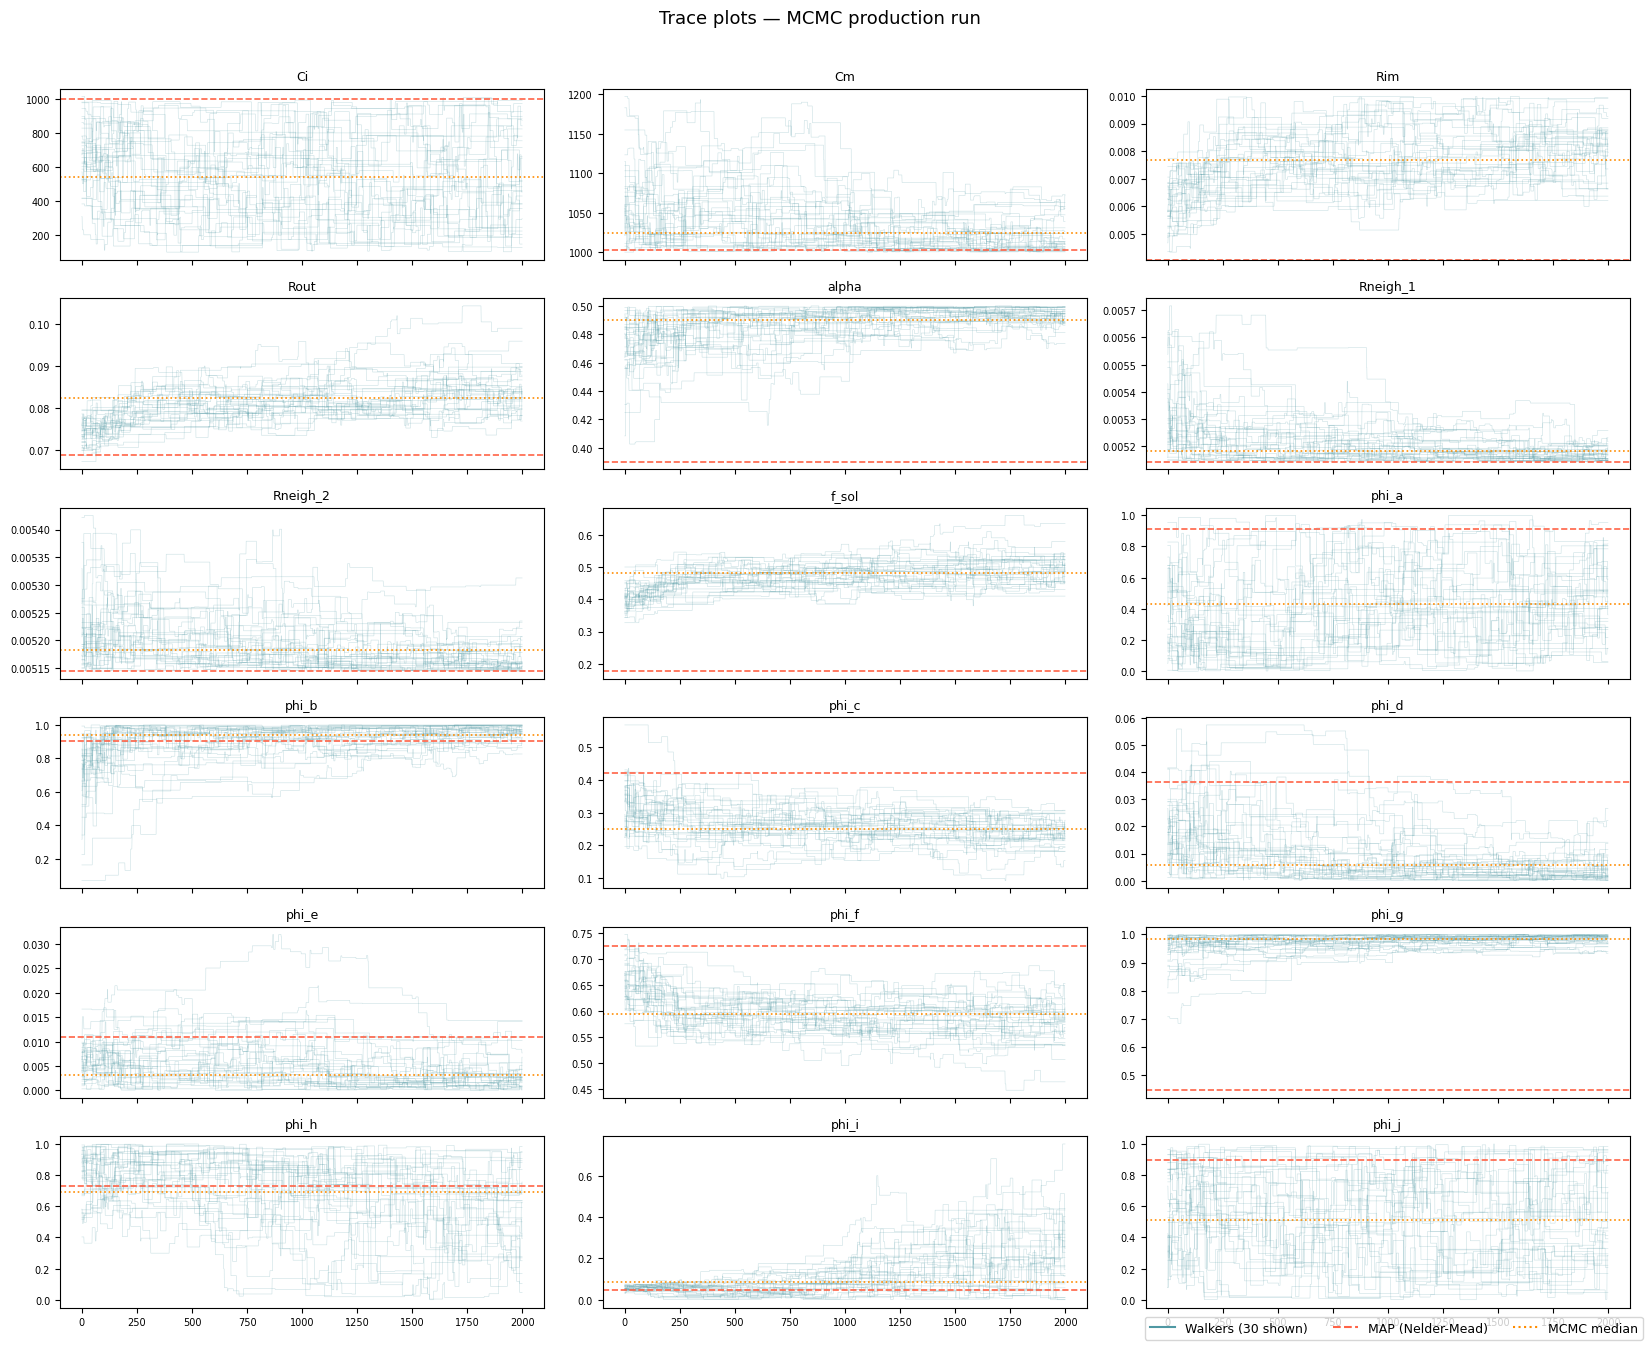

In [18]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error
import corner
import warnings
warnings.filterwarnings("ignore")

# ================================================================
# 0. LOAD
# ================================================================
RESULTS_FILE = "simulation_results_mcmc_2025_05_mcmcindic.pkl"

with open(RESULTS_FILE, "rb") as f:
    saved = pickle.load(f)

df            = saved["df"]
X_train       = saved["X_train"]
y_train       = saved["y_train"]
X_test        = saved["X_test"]
y_test        = saved["y_test"]
model         = saved["model"]
train_results = saved["train_results"]
test_results  = saved["test_results"]

flat_samples  = saved["flat_samples"]
full_chain    = saved.get("full_chain", None)
theta_map     = saved["theta_map"]
acc_frac      = saved["acceptance_fraction"]
tau           = saved["autocorr_tau"]
PARAM_NAMES   = saved["param_names"]
BOUNDS        = saved["bounds"]
sigma_obs     = saved.get("sigma_obs", 0.3)

ndim         = len(PARAM_NAMES)
N_samples    = flat_samples.shape[0]
theta_mcmc   = np.array([np.percentile(flat_samples[:, i], 50) for i in range(ndim)])

X_dict_train = {col: X_train[col].values for col in X_train.columns}
X_dict_test  = {col: X_test[col].values  for col in X_test.columns}
y_obs_train  = y_train.values
y_obs_test   = y_test.values

rmse_fn = lambda y, yh: float(np.sqrt(np.mean((np.asarray(y) - np.asarray(yh))**2)))
r2_fn   = lambda y, yh: float(1 - np.sum((np.asarray(y)-np.asarray(yh))**2)
                                   / np.sum((np.asarray(y)-np.mean(y))**2))

print(f"Loaded — {N_samples:,} posterior samples, {ndim} parameters")

# ================================================================
# 1. SAMPLER HEALTH
# ================================================================
print("\n" + "="*62)
print("  1. SAMPLER HEALTH")
print("="*62)

if   acc_frac < 0.10: acc_label = "⚠ TOO LOW  — walkers stuck, widen bounds or increase nsteps"
elif acc_frac > 0.70: acc_label = "⚠ TOO HIGH — proposals too small"
else:                  acc_label = "✓ healthy"
print(f"\n  Acceptance fraction : {acc_frac:.3f}  {acc_label}")
print(f"  (target range: 0.20 – 0.50)\n")

print(f"  {'Parameter':12s}  {'tau':>7}  {'50×tau':>7}  {'ESS':>7}  Status")
print("  " + "-"*50)
for i, name in enumerate(PARAM_NAMES):
    t   = tau[i]
    ess = N_samples / t if not np.isnan(t) else np.nan
    flag = ("⚠ need more steps" if (not np.isnan(t) and N_samples < 50*t)
            else "✓")
    print(f"  {name:12s}  {t:7.1f}  {50*t:7.0f}  {ess:7.0f}  {flag}")

# ================================================================
# 2. TRACE PLOTS
# ================================================================
if full_chain is not None:
    nsteps, nwalkers, _ = full_chain.shape
    ncols = 3
    nrows = int(np.ceil(ndim / ncols))

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5.5*ncols, 2.2*nrows), sharex=True)
    axes = axes.flatten()

    for i, name in enumerate(PARAM_NAMES):
        ax = axes[i]
        for w in range(min(nwalkers, 30)):
            ax.plot(full_chain[:, w, i], lw=0.4, alpha=0.3, color="#4f98a3")
        ax.axhline(theta_map[i],  color="tomato",     lw=1.2, ls="--")
        ax.axhline(theta_mcmc[i], color="darkorange",  lw=1.2, ls=":")
        ax.set_title(name, fontsize=9)
        ax.tick_params(labelsize=7)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    handles = [
        Line2D([0],[0], color="#4f98a3",   lw=1.5, label="Walkers (30 shown)"),
        Line2D([0],[0], color="tomato",     lw=1.5, ls="--", label="MAP (Nelder-Mead)"),
        Line2D([0],[0], color="darkorange", lw=1.5, ls=":",  label="MCMC median"),
    ]
    fig.legend(handles=handles, loc="lower right", fontsize=9, ncol=3)
    fig.suptitle("Trace plots — MCMC production run", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("mcmc_trace_plots.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\n  → mcmc_trace_plots.png saved")
else:
    print("\n  ⚠ full_chain not found in pickle — re-save to enable trace plots")

# ================================================================
# 3. CORNER PLOT
# ================================================================
fig_c = corner.corner(
    flat_samples,
    labels=PARAM_NAMES,
    truths=theta_map,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 8},
    label_kwargs={"fontsize": 8},
    truth_color="tomato",
    color="#4f98a3",
)
fig_c.suptitle("Posterior distributions — MCMC  (red = MAP)", y=1.01, fontsize=11)
plt.savefig("mcmc_corner_plot.png", dpi=120, bbox_inches="tight")
plt.show()
print("  → mcmc_corner_plot.png saved")

# ================================================================
# 4. PARAMETER ESTIMATES TABLE
# ================================================================
print("\n" + "="*62)
print("  4. PARAMETER ESTIMATES")
print("="*62)

rows = []
for i, name in enumerate(PARAM_NAMES):
    lo, hi        = BOUNDS[name]
    p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    map_val       = theta_map[i]
    shift_pct     = abs(p50 - map_val) / max(abs(map_val), 1e-12) * 100
    hit_lo = abs(p16 - lo) / max(hi - lo, 1e-10) < 0.02
    hit_hi = abs(p84 - hi) / max(hi - lo, 1e-10) < 0.02
    status = ("⚠ lower bound" if hit_lo else
              "⚠ upper bound" if hit_hi else "✓")
    rows.append({
        "Parameter":    name,
        "MAP":          f"{map_val:.5g}",
        "Median":       f"{p50:.5g}",
        "-1σ":          f"{p50-p16:.5g}",
        "+1σ":          f"{p84-p50:.5g}",
        "Δ MAP→med %":  f"{shift_pct:.1f}",
        "Bounds":       f"[{lo:.3g}, {hi:.3g}]",
        "Status":       status,
    })

param_df = pd.DataFrame(rows)
try:
    display(param_df)
except NameError:
    print(param_df.to_string(index=False))

# ================================================================
# 5. PREDICTIONS  (MAP from saved results + MCMC median recomputed)
# ================================================================
print("\n  Computing MCMC median predictions ...")

Ti_map_train = np.asarray(train_results.Z, dtype=float)
Ti_map_test  = np.asarray(test_results.Z,  dtype=float)

Ti_mcmc_train, Ti_mcmc_test = run_model_with_theta_and_ic(
    theta_mcmc, X_dict_train, X_dict_test, y_obs_train,
    train_params_TiTmCn2R2C_summer_V4
)

# ── Scalar metrics table ─────────────────────────────────────────
print("\n" + "="*62)
print("  5. SCALAR PERFORMANCE METRICS")
print("="*62)

metric_rows = []
for label, tr, te in [
    ("MAP (Nelder-Mead)", Ti_map_train,  Ti_map_test),
    ("MCMC median",       Ti_mcmc_train, Ti_mcmc_test),
]:
    metric_rows.append({
        "Model":           label,
        "RMSE train [°C]": round(rmse_fn(y_obs_train, tr), 4),
        "RMSE test  [°C]": round(rmse_fn(y_obs_test,  te), 4),
        "ΔRMSE (t-tr)":    round(rmse_fn(y_obs_test, te) - rmse_fn(y_obs_train, tr), 4),
        "R² train":        round(r2_fn(y_obs_train, tr), 4),
        "R² test":         round(r2_fn(y_obs_test,  te), 4),
    })

metrics_df = pd.DataFrame(metric_rows)
try:
    display(metrics_df)
except NameError:
    print(metrics_df.to_string(index=False))

# ================================================================
# 6. POSTERIOR PREDICTIVE CHECK + COVERAGE
# ================================================================
print("\n  Running posterior predictive check (300 samples) ...")

rng_ppc  = np.random.default_rng(42)
idx_ppc  = rng_ppc.integers(N_samples, size=300)

Ti_ens_train = np.stack([
    run_model_with_theta_and_ic(
        flat_samples[i], X_dict_train, X_dict_test, y_obs_train,
        train_params_TiTmCn2R2C_summer_V4)[0]
    for i in idx_ppc
])
Ti_ens_test = np.stack([
    run_model_with_theta_and_ic(
        flat_samples[i], X_dict_train, X_dict_test, y_obs_train,
        train_params_TiTmCn2R2C_summer_V4)[1]
    for i in idx_ppc
])

def coverage_band(ens, y_obs, sigma_obs):
    mu        = ens.mean(axis=0)
    sig_param = ens.std(axis=0)
    sig_total = np.sqrt(sig_param**2 + sigma_obs**2)

    cov_param = np.mean((y_obs >= mu - 2*sig_param) &
                        (y_obs <= mu + 2*sig_param)) * 100
    cov_total = np.mean((y_obs >= mu - 2*sig_total) &
                        (y_obs <= mu + 2*sig_total)) * 100
    return mu, sig_param, sig_total, cov_param, cov_total

mu_tr, sp_tr, st_tr, cov_param_tr, cov_total_tr = coverage_band(Ti_ens_train, y_obs_train, sigma_obs)
mu_te, sp_te, st_te, cov_param_te, cov_total_te = coverage_band(Ti_ens_test,  y_obs_test,  sigma_obs)

print("\n" + "="*62)
print("  6. POSTERIOR PREDICTIVE BAND")
print("="*62)
print(f"\n  {'':30s}  {'Train':>9}  {'Test':>9}")
print(f"  {'Parametric σ only [°C]':30s}  {sp_tr.mean():>9.4f}  {sp_te.mean():>9.4f}")
print(f"  {'Obs. noise σ [°C]':30s}  {sigma_obs:>9.4f}  {sigma_obs:>9.4f}")
print(f"  {'Total prediction σ [°C]':30s}  {st_tr.mean():>9.4f}  {st_te.mean():>9.4f}")
print(f"  {'Ratio param/total σ':30s}  {sp_tr.mean()/st_tr.mean():>9.3f}  {sp_te.mean()/st_te.mean():>9.3f}")
print(f"  {'─'*44}")
print(f"  {'±2σ coverage — param only (inner)':30s}  {cov_param_tr:>8.1f}%  {cov_param_te:>8.1f}%")
print(f"  {'±2σ coverage — total    (outer)':30s}  {cov_total_tr:>8.1f}%  {cov_total_te:>8.1f}%")
print(f"  {'(ideal for total: ~95%)':30s}")

if   cov_total_tr < 90: print("\n  ⚠ Total coverage too low  → increase sigma_obs")
elif cov_total_tr > 99: print("\n  ⚠ Total coverage too high → decrease sigma_obs")
else:                   print("\n  ✓ Total coverage looks calibrated")

if cov_param_tr < 50:
    print(f"  ⚠ Parametric coverage low ({cov_param_tr:.1f}%) — expected if sampler not converged")

# ================================================================
# 7. PREDICTION PLOT — two bands: parametric only + total
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

for ax, mu, sp, st, y_obs, ens, Ti_map, label, col in [
    (axes[0], mu_tr, sp_tr, st_tr, y_obs_train, Ti_ens_train,
     Ti_map_train, "Train", "steelblue"),
    (axes[1], mu_te, sp_te, st_te, y_obs_test,  Ti_ens_test,
     Ti_map_test,  "Test",  "darkorange"),
]:
    t = np.arange(len(y_obs))

    # ── Outer band: total uncertainty (param + obs noise) ────────
    ax.fill_between(t, mu - 2*st, mu + 2*st,
                    color=col, alpha=0.15,
                    label=f"±2σ total  ({st.mean():.3f} °C)")

    # ── Inner band: parametric uncertainty only ───────────────────
    ax.fill_between(t, mu - 2*sp, mu + 2*sp,
                    color=col, alpha=0.55,
                    label=f"±2σ param  ({sp.mean():.3f} °C)")

    ax.plot(t, y_obs,  "k-",  lw=1.0, label="Observed Tᵢ")
    ax.plot(t, Ti_map, "r--", lw=1.0, label="MAP (Nelder-Mead)")
    ax.plot(t, mu,     "-",   lw=1.4, color=col, label="MCMC median")

    ax.set_title(f"{label} period", fontsize=11)
    ax.set_xlabel("Time step [5 min]")
    ax.set_ylabel("Indoor temperature [°C]")
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle(
    f"Posterior predictive check — MCMC\n"
    f"inner band = parametric uncertainty only  |  "
    f"outer band = total (param + σ_obs={sigma_obs:.2f} °C)",
    fontsize=11
)
plt.tight_layout()
plt.savefig("mcmc_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → mcmc_predictions.png saved")

# ================================================================
# 8. RESIDUAL DIAGNOSTICS  (MCMC median, train set)
# ================================================================
print("\n" + "="*62)
print("  8. RESIDUAL DIAGNOSTICS  (MCMC median, train set)")
print("="*62)

z      = y_obs_train - Ti_mcmc_train
T_res  = len(z)
mu_z   = float(np.mean(z))
std_z  = float(np.std(z))
skew   = float(stats.skew(z))
kurt   = float(stats.kurtosis(z))       # excess kurtosis

# Shapiro-Wilk — subsample to ≤5000 points (test requirement)
z_sw            = z[::max(1, T_res//5000)]
sw_stat, sw_pval = stats.shapiro(z_sw)

# QQ-plot R²
(qq_t, qq_e), (slope_qq, int_qq, r_qq) = stats.probplot(z, dist="norm", fit=True)

# Ljung-Box
lb = acorr_ljungbox(z, lags=40, return_df=True)
n_rej = int((lb["lb_pvalue"] < 0.05).sum())

print(f"\n  Mean residual        : {mu_z:+.5f} °C  (ideal: 0)")
print(f"  Std residual         : {std_z:.5f} °C")
print(f"  Skewness  γ₁         : {skew:.4f}  (ideal: 0)")
print(f"  Excess kurtosis γ₂   : {kurt:.4f}  (ideal: 0, >0 = heavy tails)")
print(f"  Shapiro-Wilk         : W={sw_stat:.4f}, p={sw_pval:.2e}  "
      f"({'⚠ reject normality' if sw_pval < 0.05 else '✓ not rejected'})")
print(f"  Q-Q R²               : {r_qq**2:.4f}  "
      f"({'✓ acceptable' if r_qq**2 >= 0.98 else '⚠ below 0.98'})")
print(f"  Ljung-Box (1–40 lags): {n_rej}/40 significant  "
      f"({'⚠ autocorrelation present' if n_rej > 2 else '✓ white noise'})")

# ── Residual diagnostics figure ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Panel A — Histogram
ax = axes[0, 0]
ax.hist(z, bins=80, density=True, color="steelblue",
        alpha=0.70, edgecolor="white", linewidth=0.3)
xr = np.linspace(z.min(), z.max(), 400)
ax.plot(xr, stats.norm.pdf(xr, mu_z, std_z), "r-", lw=2, label="N(μ, σ²)")
ax.set_title("Residual distribution", fontsize=11)
ax.set_xlabel("Residual [°C]")
ax.set_ylabel("Density")
ax.text(0.97, 0.95,
        f"γ₁ = {skew:+.3f}\nγ₂ = {kurt:+.3f}\nSW p = {sw_pval:.1e}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        family="monospace",
        bbox=dict(fc="white", ec="#cccccc", alpha=0.85, boxstyle="round,pad=0.3"))
ax.legend(fontsize=9)

# Panel B — QQ plot
ax = axes[0, 1]
ax.scatter(qq_t, qq_e, s=4, alpha=0.35, color="steelblue", zorder=2)
xl = np.array([qq_t.min(), qq_t.max()])
ax.plot(xl, slope_qq*xl + int_qq, "r-", lw=1.8, label=f"Linear fit  R² = {r_qq**2:.4f}")
ax.set_title("Q–Q plot (vs. standard normal)", fontsize=11)
ax.set_xlabel("Theoretical quantiles")
ax.set_ylabel("Sample quantiles")
ax.legend(fontsize=9)

# Panel C — ACF
ax = axes[1, 0]
max_lag  = 60
lags_acf = np.arange(1, max_lag + 1)
acf_vals = np.array([float(pd.Series(z).autocorr(lag=l)) for l in lags_acf])
conf     = 1.96 / np.sqrt(T_res)
ax.bar(lags_acf, acf_vals, width=0.65, color="steelblue", alpha=0.75)
ax.axhline( conf, color="red", ls="--", lw=1.2, label="±95% CI")
ax.axhline(-conf, color="red", ls="--", lw=1.2)
ax.axhline(0,     color="black", lw=0.7)
ax.set_title("Autocorrelation function", fontsize=11)
ax.set_xlabel("Lag")
ax.set_ylabel("ACF")
ax.legend(fontsize=9)

# Panel D — Ljung-Box p-values
ax = axes[1, 1]
lags_lb = lb.index.values
pvals   = lb["lb_pvalue"].values
colors  = np.where(pvals < 0.05, "tomato", "steelblue")
ax.scatter(lags_lb, pvals, c=colors, s=30, zorder=3)
ax.axhline(0.05, color="red", ls="--", lw=1.5, label="α = 0.05")
ax.set_ylim(-0.02, 1.05)
ax.set_title("Ljung-Box p-values (lags 1–40)", fontsize=11)
ax.set_xlabel("Lag h")
ax.set_ylabel("p-value")
ax.legend(fontsize=9)

fig.suptitle("Residual diagnostics — MCMC median (train set)", fontsize=13)
plt.tight_layout()
plt.savefig("mcmc_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → mcmc_residual_diagnostics.png saved")

# ================================================================
# 9. SUMMARY DASHBOARD
# ================================================================
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.40)

# Panel A — Acceptance fraction
ax_a = fig.add_subplot(gs[0])
col_a = ("tomato" if acc_frac < 0.10 or acc_frac > 0.70 else "steelblue")
ax_a.barh([""], [acc_frac], color=col_a, height=0.35)
ax_a.axvline(0.20, color="green", ls="--", lw=1.5)
ax_a.axvline(0.50, color="green", ls="--", lw=1.5, label="Target [0.20, 0.50]")
ax_a.set_xlim(0, 1)
ax_a.set_xlabel("Fraction")
ax_a.set_title("Acceptance fraction", fontsize=11)
ax_a.text(min(acc_frac + 0.03, 0.92), 0,
          f"{acc_frac:.3f}", va="center", fontsize=11, color=col_a, fontweight="bold")
ax_a.legend(fontsize=8)

# Panel B — RMSE train / test
ax_b = fig.add_subplot(gs[1])
x_b  = np.array([0, 1])
rmse_map_tr   = rmse_fn(y_obs_train, Ti_map_train)
rmse_map_te   = rmse_fn(y_obs_test,  Ti_map_test)
rmse_mcmc_tr  = rmse_fn(y_obs_train, Ti_mcmc_train)
rmse_mcmc_te  = rmse_fn(y_obs_test,  Ti_mcmc_test)
ax_b.bar(x_b - 0.20, [rmse_map_tr,  rmse_mcmc_tr],  0.35,
         label="Train", color="steelblue", alpha=0.85)
ax_b.bar(x_b + 0.20, [rmse_map_te,  rmse_mcmc_te],  0.35,
         label="Test",  color="darkorange", alpha=0.85)
ax_b.axhline(0.30, color="red", ls="--", lw=1.3, label="0.30 °C threshold")
ax_b.set_xticks(x_b)
ax_b.set_xticklabels(["MAP\n(Nelder-Mead)", "MCMC\nmedian"], fontsize=9)
ax_b.set_ylabel("RMSE [°C]")
ax_b.set_title("RMSE comparison", fontsize=11)
ax_b.legend(fontsize=8)

# Panel C — Coverage
ax_c = fig.add_subplot(gs[2])
bars_c = ax_c.bar(["Train", "Test"], [cov_tr, cov_te],
                  color=["steelblue", "darkorange"], alpha=0.85, width=0.45)
ax_c.axhline(95, color="green", ls="--", lw=1.5, label="Ideal ≈ 95 %")
ax_c.axhline(99, color="red",   ls=":",  lw=1.2, label="> 99 % overconfident")
ax_c.set_ylim(0, 108)
ax_c.set_ylabel("Coverage [%]")
ax_c.set_title("±2σ Predictive coverage", fontsize=11)
for bar, val in zip(bars_c, [cov_tr, cov_te]):
    ax_c.text(bar.get_x() + bar.get_width()/2, val + 1.5,
              f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax_c.legend(fontsize=8)

fig.suptitle("MCMC Performance Summary", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("mcmc_summary_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → mcmc_summary_dashboard.png saved")

# ================================================================
# 10. FINAL PRINTED SUMMARY
# ================================================================
print("\n" + "="*62)
print("  FULL MCMC INDICATOR SUMMARY")
print("="*62)
print(f"\n  ── Sampler health ──────────────────────────────────────")
print(f"  Acceptance fraction : {acc_frac:.3f}")
slowest_idx = int(np.nanargmax(tau))
print(f"  Slowest param (τ)   : {PARAM_NAMES[slowest_idx]}  "
      f"τ={tau[slowest_idx]:.1f}  ESS≈{N_samples/tau[slowest_idx]:.0f}")
print(f"\n  ── Predictive performance ──────────────────────────────")
print(f"  {'':22s}  {'MAP':>10}  {'MCMC med':>10}")
print(f"  {'RMSE train [°C]':22s}  {rmse_map_tr:>10.4f}  {rmse_mcmc_tr:>10.4f}")
print(f"  {'RMSE test  [°C]':22s}  {rmse_map_te:>10.4f}  {rmse_mcmc_te:>10.4f}")
print(f"  {'R² train':22s}  {r2_fn(y_obs_train,Ti_map_train):>10.4f}  "
      f"{r2_fn(y_obs_train,Ti_mcmc_train):>10.4f}")
print(f"  {'R² test':22s}  {r2_fn(y_obs_test,Ti_map_test):>10.4f}  "
      f"{r2_fn(y_obs_test,Ti_mcmc_test):>10.4f}")
print(f"\n  ── Posterior predictive band (σ_obs={sigma_obs} °C) ────")
print(f"  ±2σ coverage train  : {cov_tr:.1f}%")
print(f"  ±2σ coverage test   : {cov_te:.1f}%")
print(f"\n  ── Residual diagnostics (MCMC median, train) ───────────")
print(f"  Skewness  γ₁        : {skew:+.4f}  (ideal: 0)")
print(f"  Excess kurtosis γ₂  : {kurt:+.4f}  (ideal: 0)")
print(f"  Q-Q R²              : {r_qq**2:.4f}  (≥0.98 acceptable)")
print(f"  Ljung-Box           : {n_rej}/40 lags significant")
print("="*62)

## Train results

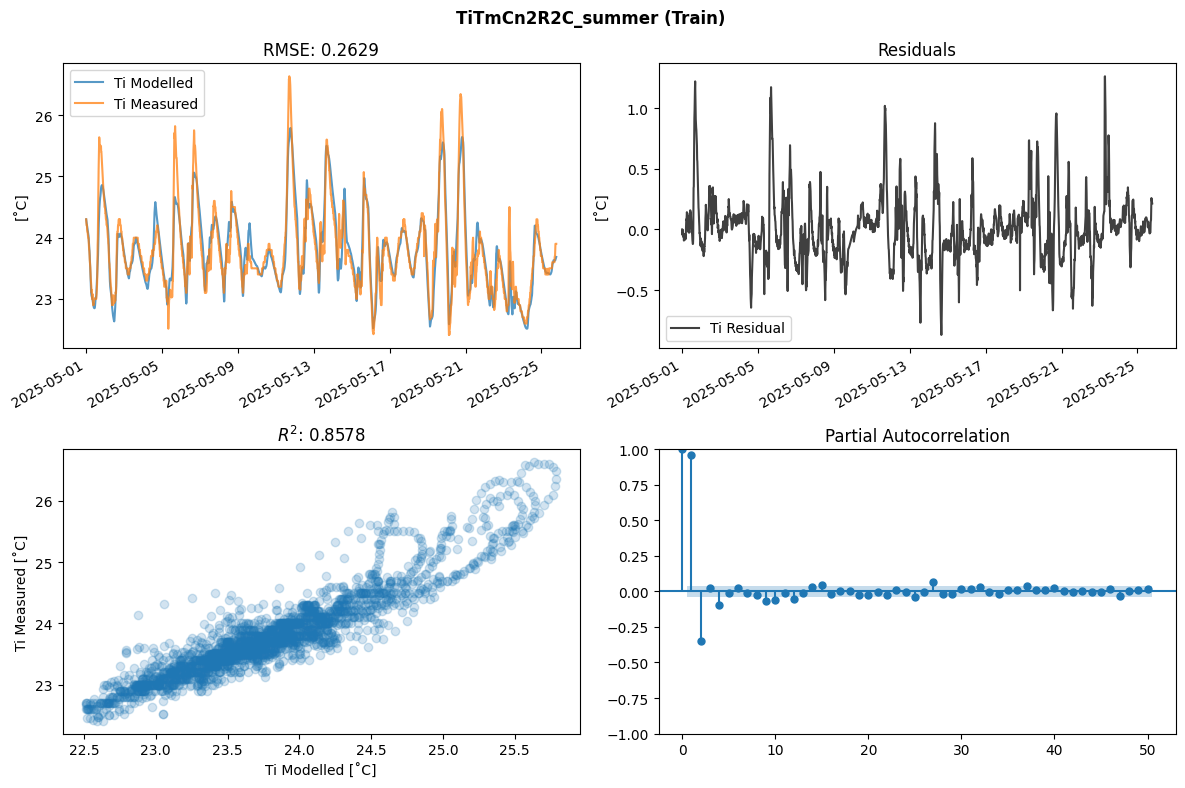

In [ ]:
plot(y_train, train_results, 'TiTmCn2R2C_summer (Train)')

In [ ]:
# ================================================================
# WIDER PARAMETRIC BAND — sample from credible intervals
# (use this when MCMC hasn't converged but you want honest uncertainty)
# ================================================================

rng_ci = np.random.default_rng(99)
n_ci_samples = 300

# Build per-parameter distributions from your MCMC percentiles
ci_samples = np.zeros((n_ci_samples, ndim))

for i, name in enumerate(PARAM_NAMES):
    p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    sigma_left  = p50 - p16
    sigma_right = p84 - p50
    sigma_avg   = (sigma_left + sigma_right) / 2.0

    lo, hi = BOUNDS[name]

    # Draw from Gaussian centred on median, width = average 1σ
    draws = rng_ci.normal(loc=p50, scale=sigma_avg, size=n_ci_samples * 5)
    # Clip to physical bounds
    draws = draws[(draws >= lo) & (draws <= hi)][:n_ci_samples]
    ci_samples[:, i] = draws

print("  Running CI-based predictive check (300 samples)...")
Ti_ci_train = np.stack([
    run_model_with_theta_and_ic(
        ci_samples[i], X_dict_train, X_dict_test, y_obs_train,
        train_params_TiTmCn2R2C_summer_V4)[0]
    for i in range(n_ci_samples)
])
Ti_ci_test = np.stack([
    run_model_with_theta_and_ic(
        ci_samples[i], X_dict_train, X_dict_test, y_obs_train,
        train_params_TiTmCn2R2C_summer_V4)[1]
    for i in range(n_ci_samples)
])

mu_ci_tr, sp_ci_tr, st_ci_tr, cov_p_tr, cov_t_tr = coverage_band(
    Ti_ci_train, y_obs_train, sigma_obs)
mu_ci_te, sp_ci_te, st_ci_te, cov_p_te, cov_t_te = coverage_band(
    Ti_ci_test,  y_obs_test,  sigma_obs)

print(f"\n  CI-based parametric σ train : {sp_ci_tr.mean():.4f} °C")
print(f"  CI-based parametric σ test  : {sp_ci_te.mean():.4f} °C")
print(f"  ±2σ param coverage train    : {cov_p_tr:.1f}%")
print(f"  ±2σ param coverage test     : {cov_p_te:.1f}%")

  Running CI-based predictive check (300 samples)...

  CI-based parametric σ train : 0.0359 °C
  CI-based parametric σ test  : 0.0306 °C
  ±2σ param coverage train    : 26.2%
  ±2σ param coverage test     : 26.3%


  σ_obs (sensor spec, ground truth) : 0.1155 °C  ← used in decomposition
  σ_obs from MAP residuals (MAD)    : 0.1848 °C  ← diagnostic reference
  σ_obs from MAP residuals (std)    : 0.2631 °C  ← inflated by occupancy spikes
  MAD / sensor ratio                : 1.60  (1.0 = perfect match)
  std / MAD  ratio                  : 1.42  (>1 → heavy tails in residuals)

  Running CI-based predictive check (300 samples)...

  UNCERTAINTY DECOMPOSITION

  σ_obs source: known sensor spec (0.1155 °C)
  Residual MAD=0.1848 °C  (ratio MAD/sensor = 1.60)  [residual std=0.2631, ratio=1.42]

                                          Train      Test
  ───────────────────────────────────────────────────────
  Parametric σ  [°C]                     0.0354    0.0301
  Observation noise σ_obs (sensor) [°C]    0.1155    0.1155
  Total prediction σ  [°C]               0.1213    0.1199
  ───────────────────────────────────────────────────────
  Parametric share  σ_p / σ_total         29.1%     25.1%
  Noise

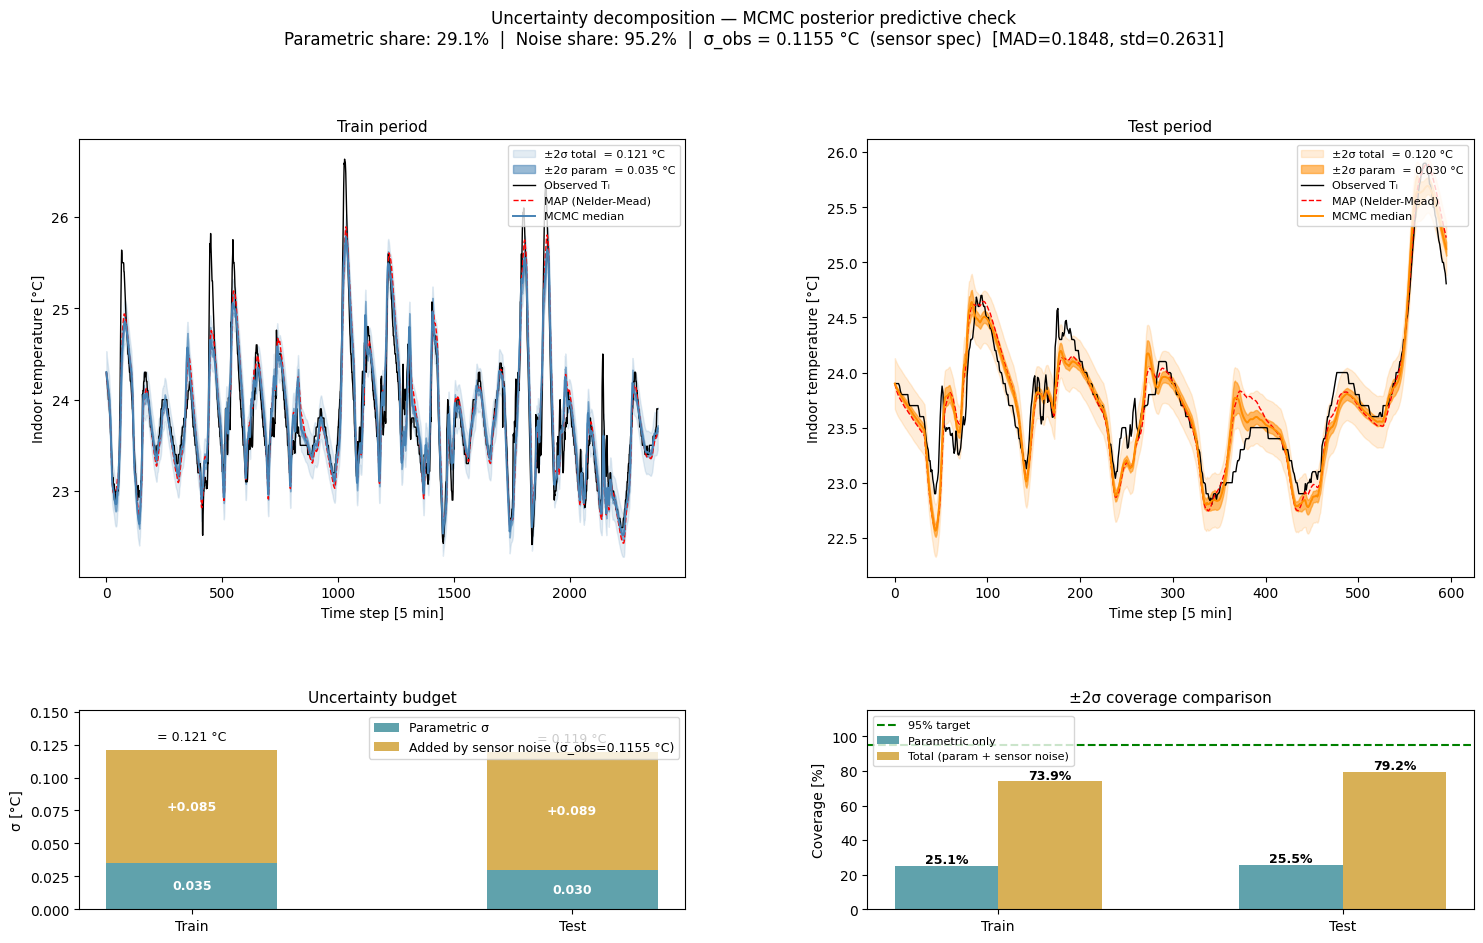

  → mcmc_uncertainty_decomposition.png saved


In [22]:
# ================================================================
# UNCERTAINTY DECOMPOSITION — full analysis + figure
# ================================================================
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.stats import median_abs_deviation


# ── 0. Observation noise: known sensor spec + MAD diagnostic ─────
# Sensor datasheet noise: σ_obs = 0.0435 °C  ← use as ground truth
#SIGMA_OBS_SENSOR = 0.0435   # °C — known sensor noise (replaces MAD estimate)
SIGMA_OBS_SENSOR = 0.1155   # °C — known sensor noise (replaces MAD estimate)

residuals_map = y_obs_train - np.asarray(train_results.Z, dtype=float)
sigma_obs_std = float(np.std(residuals_map))
sigma_obs_mad = float(median_abs_deviation(residuals_map, scale='normal'))
sigma_obs     = SIGMA_OBS_SENSOR   # ← now uses known sensor spec, not MAD

print(f"  σ_obs (sensor spec, ground truth) : {sigma_obs:.4f} °C  ← used in decomposition")
print(f"  σ_obs from MAP residuals (MAD)    : {sigma_obs_mad:.4f} °C  ← diagnostic reference")
print(f"  σ_obs from MAP residuals (std)    : {sigma_obs_std:.4f} °C  ← inflated by occupancy spikes")
print(f"  MAD / sensor ratio                : {sigma_obs_mad/sigma_obs:.2f}  (1.0 = perfect match)")
print(f"  std / MAD  ratio                  : {sigma_obs_std/sigma_obs_mad:.2f}  (>1 → heavy tails in residuals)")


# ── 1. Build CI-based samples (per-parameter Gaussian from credible interval)
rng_ci     = np.random.default_rng(99)
n_ci       = 300
ci_samples = np.zeros((n_ci, ndim))

for i, name in enumerate(PARAM_NAMES):
    p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    sigma_avg     = ((p50 - p16) + (p84 - p50)) / 2.0
    lo, hi        = BOUNDS[name]
    draws = rng_ci.normal(loc=p50, scale=sigma_avg, size=n_ci * 5)
    draws = draws[(draws >= lo) & (draws <= hi)][:n_ci]
    ci_samples[:, i] = draws

print("\n  Running CI-based predictive check (300 samples)...")
Ti_ci_train = np.stack([
    run_model_with_theta_and_ic(
        ci_samples[i], X_dict_train, X_dict_test, y_obs_train,
        train_params_TiTmCn2R2C_summer_V4)[0]
    for i in range(n_ci)
])
Ti_ci_test = np.stack([
    run_model_with_theta_and_ic(
        ci_samples[i], X_dict_train, X_dict_test, y_obs_train,
        train_params_TiTmCn2R2C_summer_V4)[1]
    for i in range(n_ci)
])


# ── 2. Compute all band quantities ───────────────────────────────
def decompose(ens, y_obs, sigma_obs):
    mu    = ens.mean(axis=0)
    sp    = ens.std(axis=0)
    st    = np.sqrt(sp**2 + sigma_obs**2)
    cov_p = np.mean((y_obs >= mu-2*sp) & (y_obs <= mu+2*sp)) * 100
    cov_t = np.mean((y_obs >= mu-2*st) & (y_obs <= mu+2*st)) * 100
    return mu, sp, st, cov_p, cov_t

mu_tr, sp_tr, st_tr, cov_p_tr, cov_t_tr = decompose(Ti_ci_train, y_obs_train, sigma_obs)
mu_te, sp_te, st_te, cov_p_te, cov_t_te = decompose(Ti_ci_test,  y_obs_test,  sigma_obs)


# ── 3. Print summary ─────────────────────────────────────────────
print("\n" + "="*62)
print("  UNCERTAINTY DECOMPOSITION")
print("="*62)
print(f"\n  σ_obs source: known sensor spec ({sigma_obs:.4f} °C)")
print(f"  Residual MAD={sigma_obs_mad:.4f} °C  (ratio MAD/sensor "
      f"= {sigma_obs_mad/sigma_obs:.2f})  "
      f"[residual std={sigma_obs_std:.4f}, ratio={sigma_obs_std/sigma_obs_mad:.2f}]\n")
print(f"  {'':35s}  {'Train':>8}  {'Test':>8}")
print(f"  {'─'*55}")
print(f"  {'Parametric σ  [°C]':35s}  {sp_tr.mean():>8.4f}  {sp_te.mean():>8.4f}")
print(f"  {'Observation noise σ_obs (sensor) [°C]':35s}  {sigma_obs:>8.4f}  {sigma_obs:>8.4f}")
print(f"  {'Total prediction σ  [°C]':35s}  {st_tr.mean():>8.4f}  {st_te.mean():>8.4f}")
print(f"  {'─'*55}")
print(f"  {'Parametric share  σ_p / σ_total':35s}  "
      f"{sp_tr.mean()/st_tr.mean()*100:>7.1f}%  {sp_te.mean()/st_te.mean()*100:>7.1f}%")
print(f"  {'Noise share  σ_obs / σ_total':35s}  "
      f"{sigma_obs/st_tr.mean()*100:>7.1f}%  {sigma_obs/st_te.mean()*100:>7.1f}%")
print(f"  {'─'*55}")
print(f"  {'±2σ coverage — parametric only':35s}  {cov_p_tr:>7.1f}%  {cov_p_te:>7.1f}%")
print(f"  {'±2σ coverage — total (target~95%)':35s}  {cov_t_tr:>7.1f}%  {cov_t_te:>7.1f}%")
print(f"\n  Interpretation:")
print(f"  → Knowing parameters better would reduce σ_total by only "
      f"{(1 - sp_tr.mean()/st_tr.mean())*100:.0f}%")
print(f"  → Dominant uncertainty source: sensor noise "
      f"({sigma_obs/st_tr.mean()*100:.0f}% of total)")


# ── 4. Figure ────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        height_ratios=[2.2, 1],
                        hspace=0.42, wspace=0.30)

ax_tr  = fig.add_subplot(gs[0, 0])
ax_te  = fig.add_subplot(gs[0, 1])
ax_bar = fig.add_subplot(gs[1, 0])
ax_cov = fig.add_subplot(gs[1, 1])


# ── Panel A & B: predictions with both bands ─────────────────────
for ax, mu, sp, st, y_obs, Ti_map, label, col in [
    (ax_tr, mu_tr, sp_tr, st_tr, y_obs_train, Ti_map_train, "Train", "steelblue"),
    (ax_te, mu_te, sp_te, st_te, y_obs_test,  Ti_map_test,  "Test",  "darkorange"),
]:
    t = np.arange(len(y_obs))
    ax.fill_between(t, mu - 2*st, mu + 2*st,
                    color=col, alpha=0.15,
                    label=f"±2σ total  = {st.mean():.3f} °C")
    ax.fill_between(t, mu - 2*sp, mu + 2*sp,
                    color=col, alpha=0.55,
                    label=f"±2σ param  = {sp.mean():.3f} °C")
    ax.plot(t, y_obs,  "k-",  lw=1.0, label="Observed Tᵢ")
    ax.plot(t, Ti_map, "r--", lw=1.0, label="MAP (Nelder-Mead)")
    ax.plot(t, mu,     "-",   lw=1.4, color=col, label="MCMC median")
    ax.set_title(f"{label} period", fontsize=11)
    ax.set_xlabel("Time step [5 min]")
    ax.set_ylabel("Indoor temperature [°C]")
    ax.legend(fontsize=8, loc="upper right")


# ── Panel C: uncertainty budget (stacked bar) ────────────────────
periods   = ["Train", "Test"]
sp_vals   = [sp_tr.mean(), sp_te.mean()]
noise_add = [np.sqrt(sigma_obs**2 + sp_tr.mean()**2) - sp_tr.mean(),
             np.sqrt(sigma_obs**2 + sp_te.mean()**2) - sp_te.mean()]
x_bar = np.arange(2)

b1 = ax_bar.bar(x_bar, sp_vals,   0.45, label="Parametric σ",
                color="#4f98a3", alpha=0.9)
b2 = ax_bar.bar(x_bar, noise_add, 0.45, bottom=sp_vals,
                label=f"Added by sensor noise (σ_obs={sigma_obs:.4f} °C)",
                color="#d4a843", alpha=0.9)

for i, (sp, na) in enumerate(zip(sp_vals, noise_add)):
    tot = sp + na
    ax_bar.text(i, sp/2,       f"{sp:.3f}",  ha="center", va="center",
                fontsize=9, color="white", fontweight="bold")
    ax_bar.text(i, sp + na/2,  f"+{na:.3f}", ha="center", va="center",
                fontsize=9, color="white", fontweight="bold")
    ax_bar.text(i, tot + 0.005, f"= {tot:.3f} °C", ha="center", va="bottom",
                fontsize=9, color="black")

ax_bar.set_xticks(x_bar)
ax_bar.set_xticklabels(periods)
ax_bar.set_ylabel("σ [°C]")
ax_bar.set_title("Uncertainty budget", fontsize=11)
ax_bar.legend(fontsize=9)
ax_bar.set_ylim(0, max(sp_vals[0]+noise_add[0],
                       sp_vals[1]+noise_add[1]) * 1.25)


# ── Panel D: coverage bars ────────────────────────────────────────
x_cov = np.arange(2)
w     = 0.30
bars1 = ax_cov.bar(x_cov - w/2, [cov_p_tr, cov_p_te], w,
                   label="Parametric only", color="#4f98a3", alpha=0.9)
bars2 = ax_cov.bar(x_cov + w/2, [cov_t_tr, cov_t_te], w,
                   label="Total (param + sensor noise)", color="#d4a843", alpha=0.9)

ax_cov.axhline(95, color="green", ls="--", lw=1.5, label="95% target")
ax_cov.set_ylim(0, 115)
ax_cov.set_xticks(x_cov)
ax_cov.set_xticklabels(periods)
ax_cov.set_ylabel("Coverage [%]")
ax_cov.set_title("±2σ coverage comparison", fontsize=11)
ax_cov.legend(fontsize=8)

for bar, val in [(b, v) for bars, vals in
                 [(bars1, [cov_p_tr, cov_p_te]),
                  (bars2, [cov_t_tr, cov_t_te])]
                 for b, v in zip(bars, vals)]:
    ax_cov.text(bar.get_x() + bar.get_width()/2, val + 1.5,
                f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")


# ── Overall title ─────────────────────────────────────────────────
fig.suptitle(
    "Uncertainty decomposition — MCMC posterior predictive check\n"
    f"Parametric share: {sp_tr.mean()/st_tr.mean()*100:.1f}%  |  "
    f"Noise share: {sigma_obs/st_tr.mean()*100:.1f}%  |  "
    f"σ_obs = {sigma_obs:.4f} °C  (sensor spec)  "
    f"[MAD={sigma_obs_mad:.4f}, std={sigma_obs_std:.4f}]",
    fontsize=12, y=1.01
)

plt.savefig("mcmc_uncertainty_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → mcmc_uncertainty_decomposition.png saved")

In [ ]:
# Residuals between MAP prediction and observations
residuals_train = y_obs_train - np.asarray(train_results.Z)

# Simple standard deviation
sigma_obs_map = float(np.std(residuals_train))

# More robust: use median absolute deviation (less sensitive to occupancy spikes)
sigma_obs_mad = float(stats.median_abs_deviation(residuals_train, scale='normal'))

print(f"σ_obs from MAP residuals (std) : {sigma_obs_map:.4f} °C")
print(f"σ_obs from MAP residuals (MAD) : {sigma_obs_mad:.4f} °C")

# Use MAD if your residuals are skewed (yours are: γ₁ = 1.01)
sigma_obs = sigma_obs_mad

σ_obs from MAP residuals (std) : 0.2629 °C
σ_obs from MAP residuals (MAD) : 0.1833 °C


## Test results

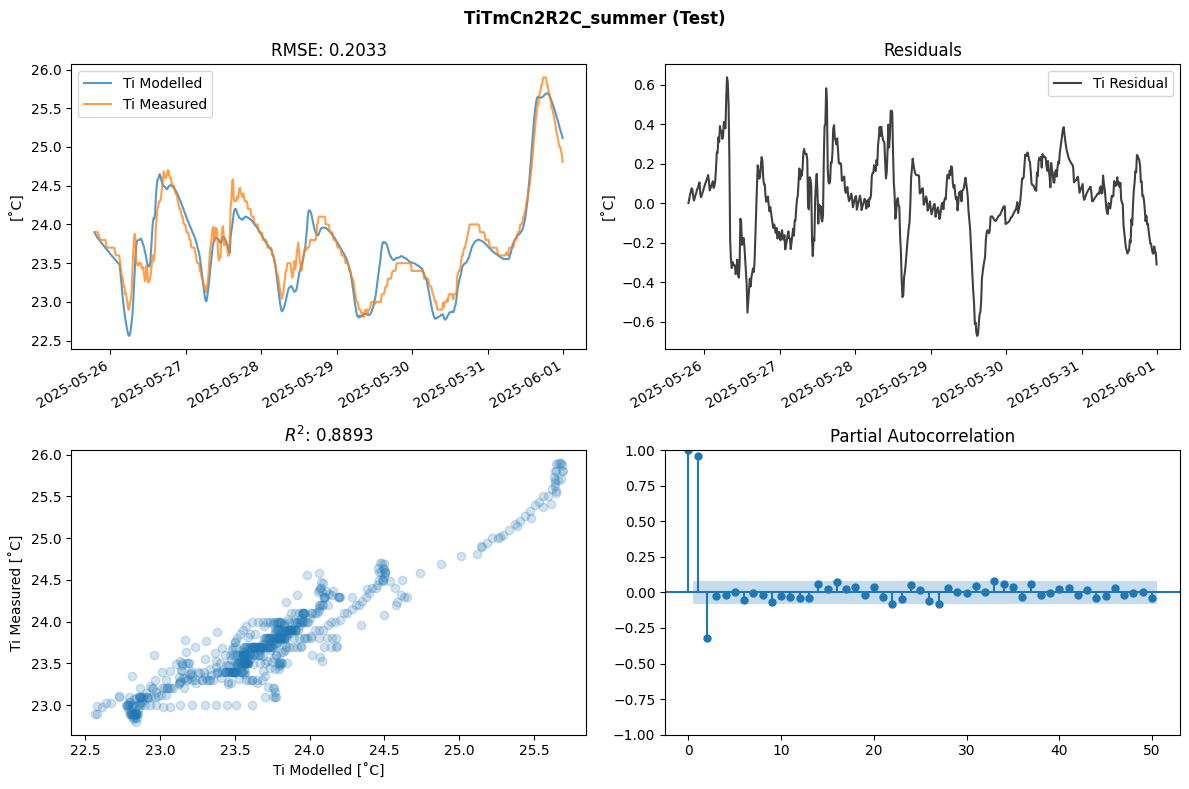

In [ ]:
plot(y_test, test_results, 'TiTmCn2R2C_summer (Test)')

         EXTENDED MODEL VALIDATION REPORT (TEST)

── GOODNESS OF FIT (free-run simulation) ───────────────────
  RMSE:              0.2148 °C
  MAE:               0.1580 °C
  NRMSE (by range):  0.0632
  R²:                0.8767

── LIKELIHOOD-BASED CRITERIA ───────────────────────────────
  Log-Likelihood:     102.2559
  AIC (lower=better): -168.5118
  BIC (lower=better): -82.8871
  Parameters varied:  18

── RESIDUAL STATISTICS (free-run) ──────────────────────────
  Mean:     -0.016795 °C  (ideal ≈ 0)
  Std Dev:  0.214310 °C
  Skewness: 1.602713    (ideal ≈ 0)
  Kurtosis: 3.274878    (ideal ≈ 0)

── RESIDUAL STATISTICS (one-step-ahead) ────────────────────
  Mean:     -0.000077 °C  (ideal ≈ 0)
  Std Dev:  0.050174 °C
  Skewness: -0.514450    (ideal ≈ 0)
  Kurtosis: 4.145552    (ideal ≈ 0)

── NORMALITY TESTS — one-step (H0: Gaussian) ──────────────
  Shapiro-Wilk:  W=0.879668,  p=3.055e-25  ✗ Not Normal
  Jarque-Bera:   JB=652.9917,  p=1.602e-142  ✗ Not Normal

── LJUNG-BOX — one-st

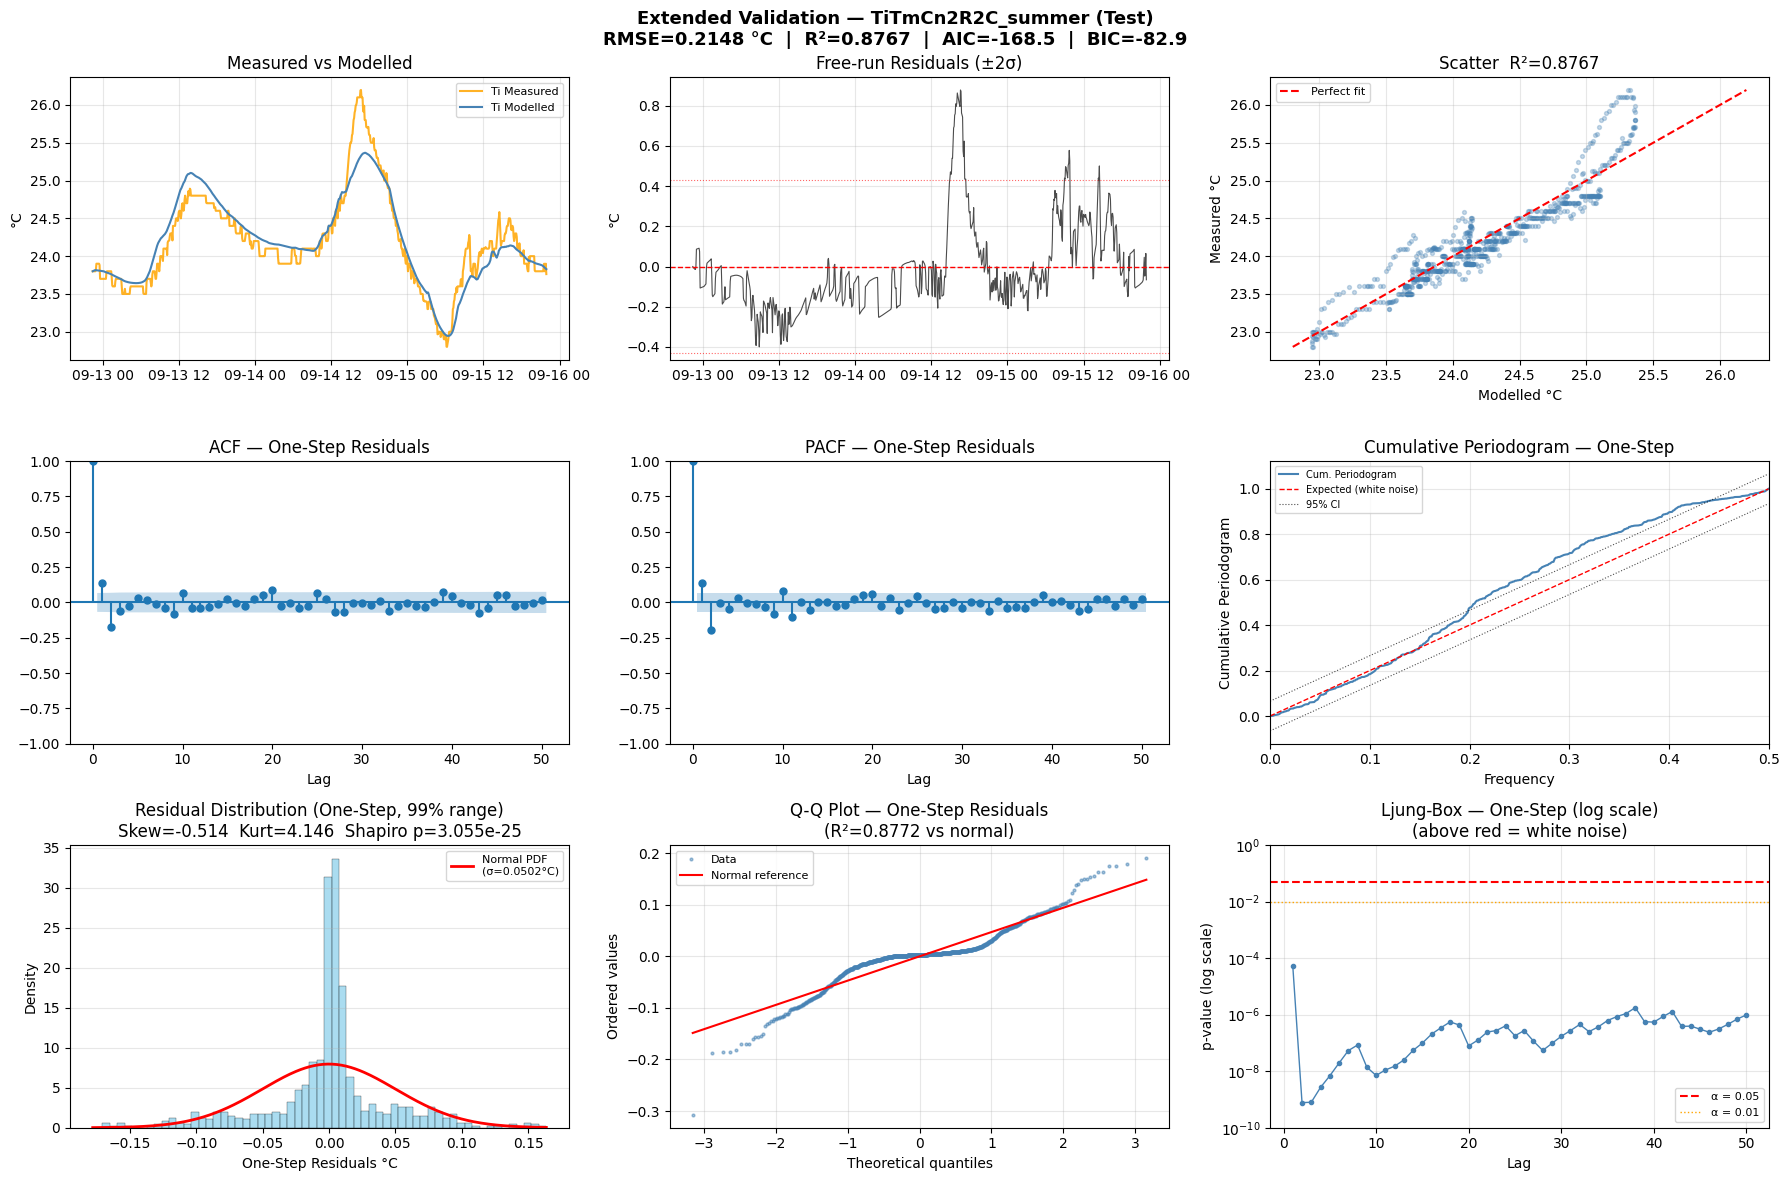

In [ ]:
# ============================================================
# EXTENDED MODEL VALIDATION — FINAL VERSION (v3)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------------------
# 1. EXTRACT RESIDUALS — TWO TYPES
# ----------------------------------------------------------
Ti_measured  = y_test.values
Ti_modelled  = test_results.var['Ti']

# FREE-RUN → RMSE, R², MAE, scatter, time series
residuals    = Ti_measured - Ti_modelled
n            = len(residuals)

# ONE-STEP-AHEAD → ACF, PACF, Periodogram, Ljung-Box
residuals_1s = np.diff(residuals)
n1           = len(residuals_1s)

# ----------------------------------------------------------
# 2. COMPUTE ALL METRICS
# ----------------------------------------------------------

# Goodness of fit (free-run)
rmse_val  = np.sqrt(np.mean(residuals**2))
mae_val   = np.mean(np.abs(residuals))
ss_res    = np.sum(residuals**2)
ss_tot    = np.sum((Ti_measured - np.mean(Ti_measured))**2)
r2_val    = 1 - (ss_res / ss_tot)
nrmse_val = rmse_val / (Ti_measured.max() - Ti_measured.min())

# Likelihood-based metrics (free-run)
sigma2  = np.var(residuals, ddof=1)
log_lik = -0.5 * n * np.log(2 * np.pi * sigma2) - 0.5 * np.sum(residuals**2) / sigma2
if 'model' in locals() and hasattr(model, 'result') and hasattr(model.result, 'params'):
    k_params = sum(1 for p in model.result.params.values() if getattr(p, 'vary', False))
else:
    k_params = sum(1 for p in train_params_TiTmCn2R2C_summer_V4.values()
                   if isinstance(p, dict) and p.get('vary', False))
aic_val = -2 * log_lik + 2 * k_params
bic_val = -2 * log_lik + k_params * np.log(n)

# Free-run residual statistics
res_mean = np.mean(residuals)
res_std  = np.std(residuals, ddof=1)
res_skew = stats.skew(residuals)
res_kurt = stats.kurtosis(residuals)

# One-step residual statistics
res1_mean = np.mean(residuals_1s)
res1_std  = np.std(residuals_1s, ddof=1)
res1_skew = stats.skew(residuals_1s)
res1_kurt = stats.kurtosis(residuals_1s)

# Normality tests (one-step)
shapiro_stat, shapiro_p = stats.shapiro(residuals_1s[:min(5000, n1)])
jb_stat, jb_p           = stats.jarque_bera(residuals_1s)

# Ljung-Box (one-step)
lb_results = acorr_ljungbox(residuals_1s, lags=[1, 6, 12, 24, 48], return_df=True)

# ----------------------------------------------------------
# 3. PRINT VALIDATION REPORT  (scientific notation for p)
# ----------------------------------------------------------
def fmt_p(p):
    """Format p-value: show more precision, switch to sci notation if tiny."""
    if p < 0.0001:
        return f"{p:.3e}"
    return f"{p:.6f}"

print("=" * 65)
print("         EXTENDED MODEL VALIDATION REPORT (TEST)")
print("=" * 65)

print("\n── GOODNESS OF FIT (free-run simulation) ───────────────────")
print(f"  RMSE:              {rmse_val:.4f} °C")
print(f"  MAE:               {mae_val:.4f} °C")
print(f"  NRMSE (by range):  {nrmse_val:.4f}")
print(f"  R²:                {r2_val:.4f}")

print("\n── LIKELIHOOD-BASED CRITERIA ───────────────────────────────")
print(f"  Log-Likelihood:     {log_lik:.4f}")
print(f"  AIC (lower=better): {aic_val:.4f}")
print(f"  BIC (lower=better): {bic_val:.4f}")
print(f"  Parameters varied:  {k_params}")

print("\n── RESIDUAL STATISTICS (free-run) ──────────────────────────")
print(f"  Mean:     {res_mean:.6f} °C  (ideal ≈ 0)")
print(f"  Std Dev:  {res_std:.6f} °C")
print(f"  Skewness: {res_skew:.6f}    (ideal ≈ 0)")
print(f"  Kurtosis: {res_kurt:.6f}    (ideal ≈ 0)")

print("\n── RESIDUAL STATISTICS (one-step-ahead) ────────────────────")
print(f"  Mean:     {res1_mean:.6f} °C  (ideal ≈ 0)")
print(f"  Std Dev:  {res1_std:.6f} °C")
print(f"  Skewness: {res1_skew:.6f}    (ideal ≈ 0)")
print(f"  Kurtosis: {res1_kurt:.6f}    (ideal ≈ 0)")

print("\n── NORMALITY TESTS — one-step (H0: Gaussian) ──────────────")
print(f"  Shapiro-Wilk:  W={shapiro_stat:.6f},  p={fmt_p(shapiro_p)}  "
      f"{'✓ Normal' if shapiro_p > 0.05 else '✗ Not Normal'}")
print(f"  Jarque-Bera:   JB={jb_stat:.4f},  p={fmt_p(jb_p)}  "
      f"{'✓ Normal' if jb_p > 0.05 else '✗ Not Normal'}")

print("\n── LJUNG-BOX — one-step (H0: white noise) ─────────────────")
print(f"  {'Lag':<6} {'Q-stat':>10} {'p-value':>14}  Result")
print(f"  {'-'*46}")
for lag in [1, 6, 12, 24, 48]:
    row    = lb_results.loc[lag]
    result = '✓ White noise' if row['lb_pvalue'] > 0.05 else '✗ Autocorrelation'
    print(f"  {lag:<6} {row['lb_stat']:>10.4f} {fmt_p(row['lb_pvalue']):>14}  {result}")
print("=" * 65)

# ----------------------------------------------------------
# 4. DIAGNOSTIC PLOTS
# ----------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle(
    f'Extended Validation — TiTmCn2R2C_summer (Test)\n'
    f'RMSE={rmse_val:.4f} °C  |  R²={r2_val:.4f}  |  AIC={aic_val:.1f}  |  BIC={bic_val:.1f}',
    fontsize=13, fontweight='bold'
)

time_idx    = y_test.index
time_idx_1s = y_test.index[1:]

# ── Plot 1: Time series ──────────────────────────────────
ax = axes[0, 0]
ax.plot(time_idx, Ti_measured, label='Ti Measured', color='orange',    lw=1.5, alpha=0.85)
ax.plot(time_idx, Ti_modelled, label='Ti Modelled', color='steelblue', lw=1.5)
ax.set_ylabel('°C')
ax.set_title('Measured vs Modelled')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Plot 2: Free-run residuals ───────────────────────────
ax = axes[0, 1]
ax.plot(time_idx, residuals, color='black', lw=0.8, alpha=0.7)
ax.axhline(0,          color='red', ls='--', lw=1)
ax.axhline( 2*res_std, color='red', ls=':',  lw=0.8, alpha=0.6)
ax.axhline(-2*res_std, color='red', ls=':',  lw=0.8, alpha=0.6)
ax.set_ylabel('°C')
ax.set_title('Free-run Residuals (±2σ)')
ax.grid(alpha=0.3)

# ── Plot 3: Scatter ──────────────────────────────────────
ax = axes[0, 2]
ax.scatter(Ti_modelled, Ti_measured, alpha=0.3, s=8, color='steelblue')
lo = min(Ti_modelled.min(), Ti_measured.min())
hi = max(Ti_modelled.max(), Ti_measured.max())
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Modelled °C'); ax.set_ylabel('Measured °C')
ax.set_title(f'Scatter  R²={r2_val:.4f}')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Plot 4: ACF (one-step) ───────────────────────────────
ax = axes[1, 0]
plot_acf(residuals_1s, lags=50, ax=ax, alpha=0.05)
ax.set_title('ACF — One-Step Residuals')
ax.set_xlabel('Lag')

# ── Plot 5: PACF (one-step) ──────────────────────────────
ax = axes[1, 1]
plot_pacf(residuals_1s, lags=50, ax=ax, alpha=0.05, method='ywm')
ax.set_title('PACF — One-Step Residuals')
ax.set_xlabel('Lag')

# ── Plot 6: Cumulative Periodogram (one-step) ────────────
ax = axes[1, 2]
freqs, Pxx = signal.periodogram(residuals_1s, fs=1.0)
cum_per    = np.cumsum(Pxx) / np.sum(Pxx)
m          = len(freqs)
K_alpha    = np.sqrt(-0.5 * np.log(0.05 / 2))
expected   = np.linspace(0, 1, m)
upper      = expected + K_alpha / np.sqrt(m)
lower      = expected - K_alpha / np.sqrt(m)
ax.plot(freqs, cum_per,  color='steelblue', lw=1.5, label='Cum. Periodogram')
ax.plot(freqs, expected, 'r--', lw=1,       label='Expected (white noise)')
ax.plot(freqs, upper,    'k:',  lw=0.8, alpha=0.7)
ax.plot(freqs, lower,    'k:',  lw=0.8, alpha=0.7, label='95% CI')
ax.set_xlim(0, 0.5)
ax.set_xlabel('Frequency'); ax.set_ylabel('Cumulative Periodogram')
ax.set_title('Cumulative Periodogram — One-Step')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# ── Plot 7: Histogram — FIX: clip x-axis to 99th percentile
ax = axes[2, 0]
p1, p99 = np.percentile(residuals_1s, 0.5), np.percentile(residuals_1s, 99.5)
res1_clipped = residuals_1s[(residuals_1s >= p1) & (residuals_1s <= p99)]
ax.hist(res1_clipped, bins=60, density=True, alpha=0.7,
        color='skyblue', edgecolor='black', lw=0.3)
x_fit = np.linspace(p1, p99, 300)
ax.plot(x_fit, stats.norm.pdf(x_fit, res1_mean, res1_std),
        'r-', lw=2, label=f'Normal PDF\n(σ={res1_std:.4f}°C)')
ax.set_xlabel('One-Step Residuals °C'); ax.set_ylabel('Density')
ax.set_title(f'Residual Distribution (One-Step, 99% range)\n'
             f'Skew={res1_skew:.3f}  Kurt={res1_kurt:.3f}  Shapiro p={fmt_p(shapiro_p)}')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

# ── Plot 8: Q-Q Plot — FIX: add reference line + annotation
ax = axes[2, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals_1s, dist='norm')
ax.plot(osm, osr,                  'o', color='steelblue', ms=2, alpha=0.5, label='Data')
ax.plot(osm, slope*np.array(osm) + intercept, 'r-', lw=1.5, label='Normal reference')
ax.set_xlabel('Theoretical quantiles'); ax.set_ylabel('Ordered values')
ax.set_title(f'Q-Q Plot — One-Step Residuals\n(R²={r**2:.4f} vs normal)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Plot 9: Ljung-Box — FIX: log scale so differences are visible
ax = axes[2, 2]
lb_all = acorr_ljungbox(residuals_1s, lags=50, return_df=True)
pvals  = lb_all['lb_pvalue'].values
lags   = lb_all.index.values
# Clip to avoid log(0)
pvals_plot = np.clip(pvals, 1e-10, 1.0)
ax.semilogy(lags, pvals_plot, 'o-', color='steelblue', ms=3, lw=1)
ax.axhline(0.05, color='red',    ls='--', lw=1.5, label='α = 0.05')
ax.axhline(0.01, color='orange', ls=':',  lw=1.0, label='α = 0.01')
ax.set_xlabel('Lag'); ax.set_ylabel('p-value (log scale)')
ax.set_title('Ljung-Box — One-Step (log scale)\n(above red = white noise)')
ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')
ax.set_ylim(1e-10, 1.0)

plt.tight_layout()
plt.show()

Baseline -log L at fitted params: 942.1684

Profiling Ci (fitted=1000.0545)  range=[1000.0000, 1600.0871]
  Ci=1000.0000  →  -logL=942.1359  Δ=-0.0325
  Ci=1025.0036  →  -logL=957.3442  Δ=15.1758
  Ci=1050.0073  →  -logL=973.0990  Δ=30.9305
  Ci=1075.0109  →  -logL=989.3602  Δ=47.1918
  Ci=1100.0145  →  -logL=1006.0891  Δ=63.9207
  Ci=1125.0182  →  -logL=1023.2486  Δ=81.0802
  Ci=1150.0218  →  -logL=1040.8027  Δ=98.6343
  Ci=1175.0254  →  -logL=1058.7168  Δ=116.5484
  Ci=1200.0290  →  -logL=1076.9580  Δ=134.7896
  Ci=1225.0327  →  -logL=1095.4945  Δ=153.3261
  Ci=1250.0363  →  -logL=1114.2960  Δ=172.1276
  Ci=1275.0399  →  -logL=1133.3336  Δ=191.1652
  Ci=1300.0436  →  -logL=1152.5797  Δ=210.4113
  Ci=1325.0472  →  -logL=1172.0080  Δ=229.8396
  Ci=1350.0508  →  -logL=1191.5937  Δ=249.4253
  Ci=1375.0545  →  -logL=1211.3131  Δ=269.1447
  Ci=1400.0581  →  -logL=1231.1436  Δ=288.9752
  Ci=1425.0617  →  -logL=1251.0642  Δ=308.8958
  Ci=1450.0654  →  -logL=1271.0548  Δ=328.8864
  Ci=1475.06

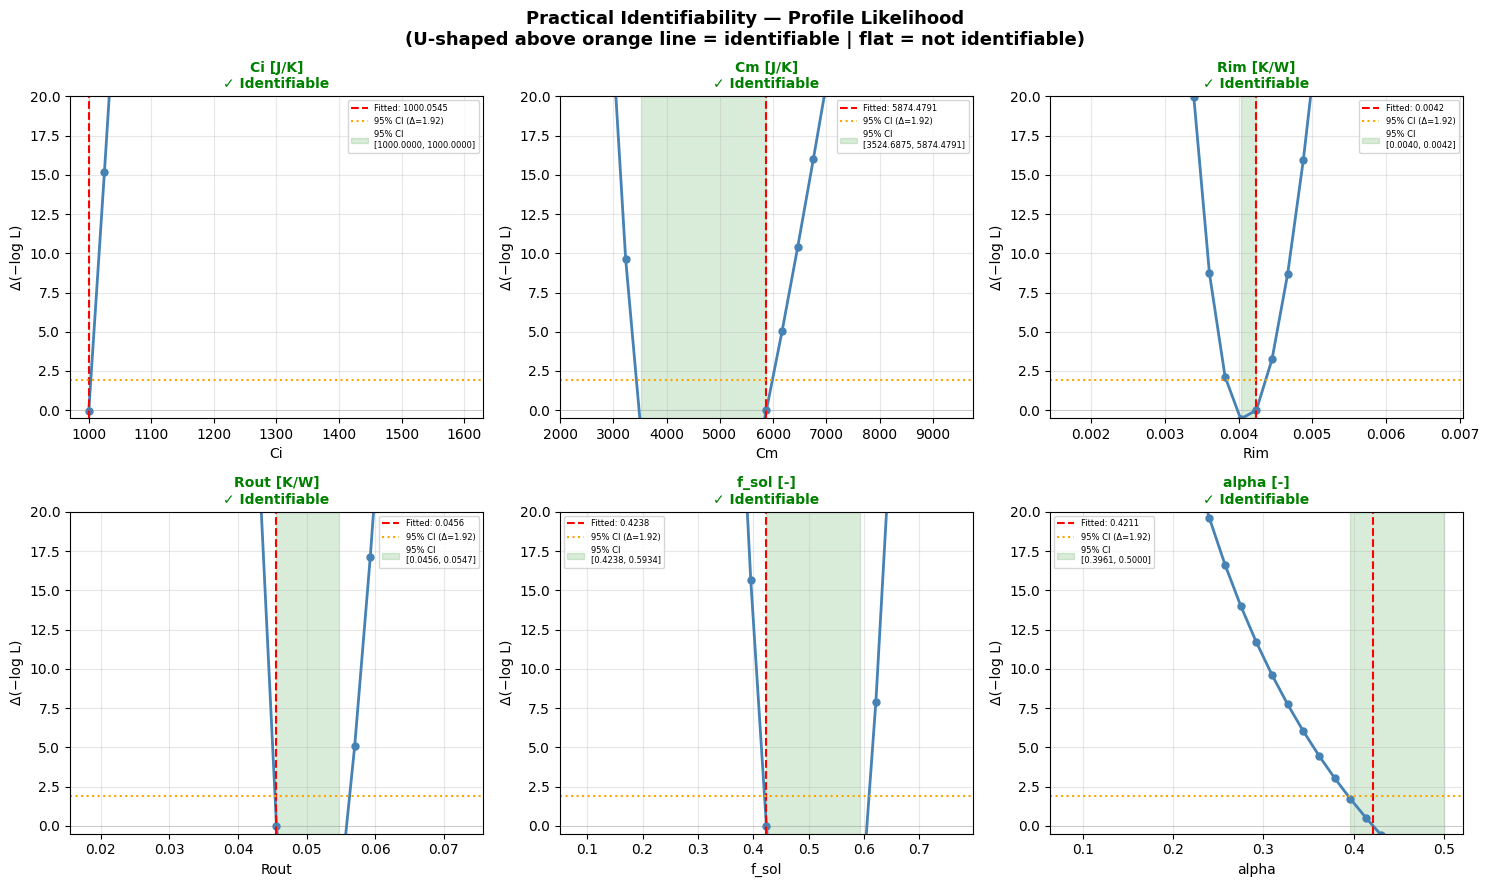

In [ ]:
# ============================================================
# PRACTICAL IDENTIFIABILITY — PROFILE LIKELIHOOD (FIXED)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import lmfit

# ----------------------------------------------------------
# HELPER — rebuild params from scratch (avoids deepcopy bug)
# ----------------------------------------------------------
def compute_nll_at_param(param_name, param_val, fitted_model, fitted_params, X, y_vals):
    """
    Fix param_name=param_val, hold all others at fitted values.
    Uses the EXISTING model instance directly — no re-instantiation.
    """
    # Build fresh lmfit Parameters (avoids deepcopy issues)
    p = lmfit.Parameters()
    for name, par in fitted_params.items():
        p.add(name,
              value = par.value,
              vary  = False,           # all fixed for forward-run
              min   = par.min if np.isfinite(par.min) else -np.inf,
              max   = par.max if np.isfinite(par.max) else  np.inf)

    # Override the one parameter being profiled
    p[param_name].value = param_val

    try:
        result  = fitted_model.model(p, X)
        Ti_pred = np.asarray(result.var['Ti'])
        res     = y_vals - Ti_pred
        n       = len(res)
        sigma2  = np.var(res, ddof=1)
        if sigma2 <= 0 or not np.isfinite(sigma2):
            return np.nan
        return 0.5 * n * np.log(2 * np.pi * sigma2) + 0.5 * np.sum(res**2) / sigma2
    except Exception as e:
        print(f"    ⚠ Error at {param_name}={param_val:.4f}: {e}")
        return np.nan


# ----------------------------------------------------------
# SETUP
# ----------------------------------------------------------
# Use the existing trained model instance from darkgreyfit
fitted_model  = model          # the DarkGreyModel instance from df.iloc[0]
fitted_params = model.result.params

# Training data — adjust variable names to match your notebook
y_train_vals = y_train.values        # numpy array
X_train_dict = X_train               # DataFrame or dict — whatever your model.model() expects

# Compute best -log L at fitted params (baseline = 0)
best_nll = compute_nll_at_param(
    'Ci', fitted_params['Ci'].value,   # dummy call with fitted value = baseline
    fitted_model, fitted_params, X_train_dict, y_train_vals
)
print(f"Baseline -log L at fitted params: {best_nll:.4f}")

# ----------------------------------------------------------
# PARAMETERS TO PROFILE
# ----------------------------------------------------------
# (param_name, display_label, n_grid_points, fraction_of_range_to_explore)
profile_params = [
    ('Ci',    'Ci [J/K]',   25, 0.60),
    ('Cm',    'Cm [J/K]',   25, 0.60),
    ('Rim',   'Rim [K/W]',  25, 0.60),
    ('Rout',  'Rout [K/W]', 25, 0.60),
    ('f_sol', 'f_sol [-]',  25, 0.80),
    ('alpha', 'alpha [-]',  25, 0.80),
]

# ----------------------------------------------------------
# COMPUTE PROFILES
# ----------------------------------------------------------
profiles = {}

for param_name, label, n_pts, rel_range in profile_params:
    if param_name not in fitted_params:
        print(f"  Skipping {param_name} — not in fitted_params")
        continue

    fitted_val = fitted_params[param_name].value
    p_min      = fitted_params[param_name].min
    p_max      = fitted_params[param_name].max

    # Grid: ±rel_range around fitted value, clamped to bounds
    lo   = max(p_min if np.isfinite(p_min) else fitted_val*0.01,
               fitted_val * (1 - rel_range))
    hi   = min(p_max if np.isfinite(p_max) else fitted_val*100,
               fitted_val * (1 + rel_range))
    grid = np.linspace(lo, hi, n_pts)

    print(f"\nProfiling {param_name} (fitted={fitted_val:.4f})  range=[{lo:.4f}, {hi:.4f}]")

    nll_vals = []
    for val in grid:
        nll = compute_nll_at_param(
            param_name, val,
            fitted_model, fitted_params,
            X_train_dict, y_train_vals
        )
        nll_vals.append(nll)
        print(f"  {param_name}={val:.4f}  →  -logL={nll:.4f}  Δ={nll - best_nll:.4f}")

    profiles[param_name] = {
        'label':      label,
        'grid':       grid,
        'nll':        np.array(nll_vals),
        'fitted_val': fitted_val,
        'best_nll':   best_nll,
    }

# ----------------------------------------------------------
# PLOT
# ----------------------------------------------------------
n_plots  = len(profiles)
ncols    = 3
nrows    = int(np.ceil(n_plots / ncols))
chi2_thr = 1.92   # χ²(1, 0.95) / 2

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows))
axes = axes.flatten()

for i, (param_name, data) in enumerate(profiles.items()):
    ax  = axes[i]
    raw = data['nll']
    delta = raw - data['best_nll']

    # Replace NaN with large value for plotting
    delta_plot = np.where(np.isfinite(delta), delta, np.nanmax(delta[np.isfinite(delta)] if np.any(np.isfinite(delta)) else [20]))

    ax.plot(data['grid'], delta_plot, 'o-', color='steelblue', lw=2, ms=5)
    ax.axvline(data['fitted_val'], color='red',    ls='--', lw=1.5,
               label=f"Fitted: {data['fitted_val']:.4f}")
    ax.axhline(chi2_thr, color='orange', ls=':', lw=1.5,
               label=f'95% CI (Δ={chi2_thr})')
    ax.axhline(0, color='gray', ls='-', lw=0.5, alpha=0.4)

    # Shade 95% CI region
    ci_mask = delta_plot <= chi2_thr
    if ci_mask.any():
        ci_lo = data['grid'][ci_mask].min()
        ci_hi = data['grid'][ci_mask].max()
        ax.axvspan(ci_lo, ci_hi, alpha=0.15, color='green',
                   label=f'95% CI\n[{ci_lo:.4f}, {ci_hi:.4f}]')

    # Verdict
    max_delta = np.nanmax(delta_plot)
    if max_delta > chi2_thr and np.nanmin(delta_plot) < 0.5:
        verdict, col = '✓ Identifiable', 'green'
    elif max_delta < chi2_thr:
        verdict, col = '✗ Not identifiable (flat)', 'red'
    else:
        verdict, col = '⚠ Weakly identifiable', 'orange'

    ax.set_title(f'{data["label"]}\n{verdict}', color=col, fontweight='bold', fontsize=10)
    ax.set_xlabel(param_name); ax.set_ylabel('Δ(−log L)')
    ax.legend(fontsize=6); ax.grid(alpha=0.3)
    ax.set_ylim(-0.5, min(max_delta * 1.1 + 1, 20))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Practical Identifiability — Profile Likelihood\n'
             '(U-shaped above orange line = identifiable | flat = not identifiable)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Plot the different heat gains

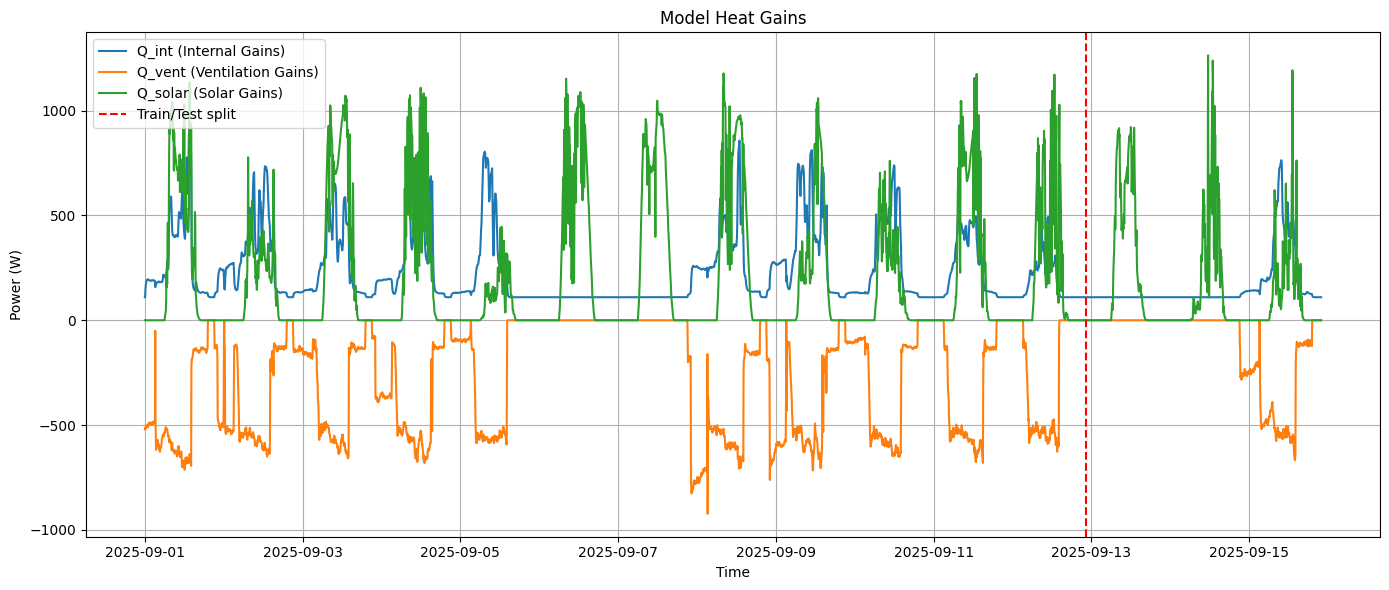

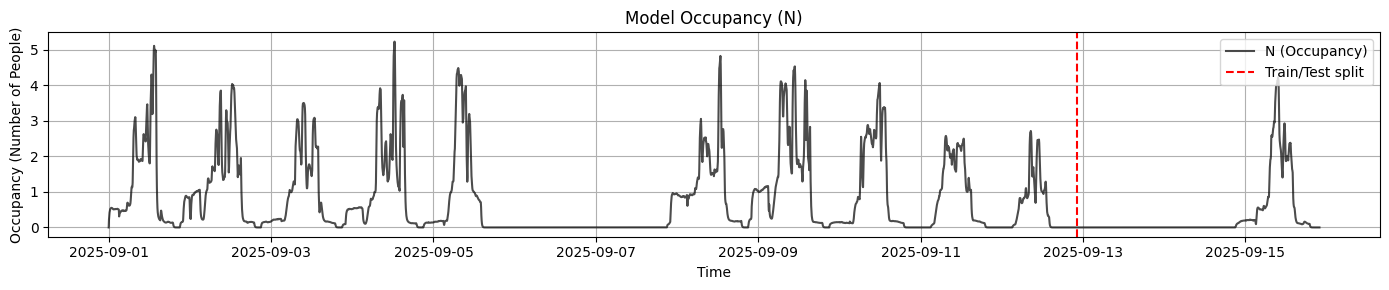

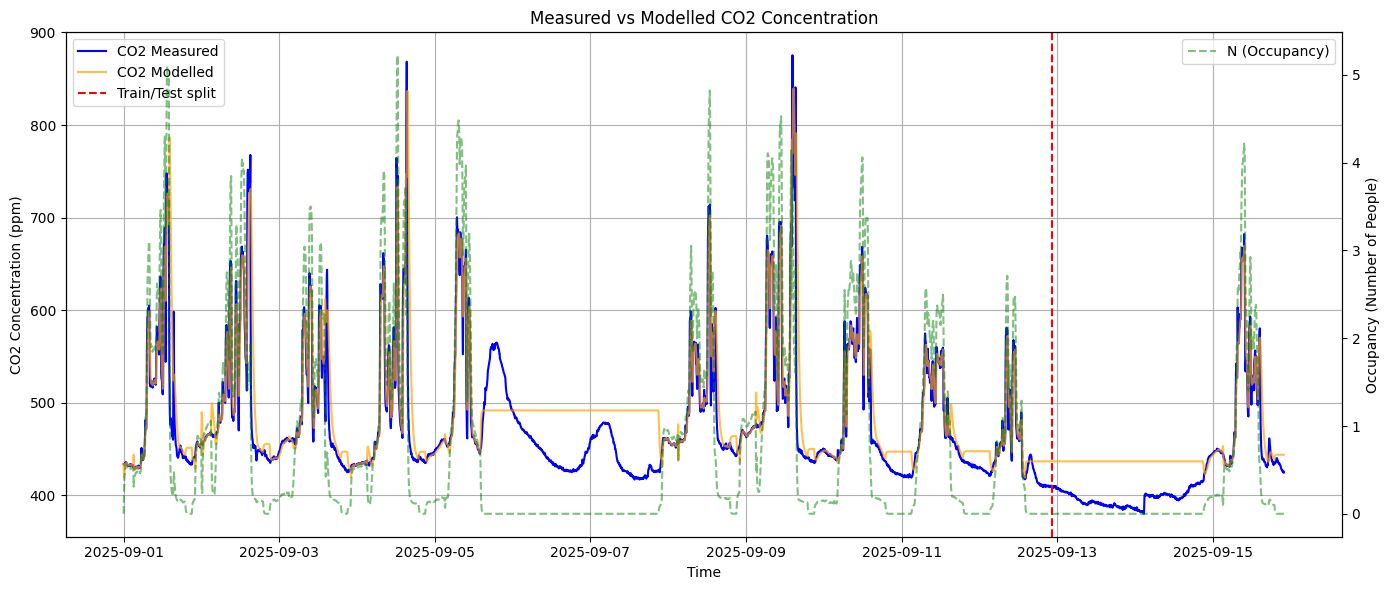

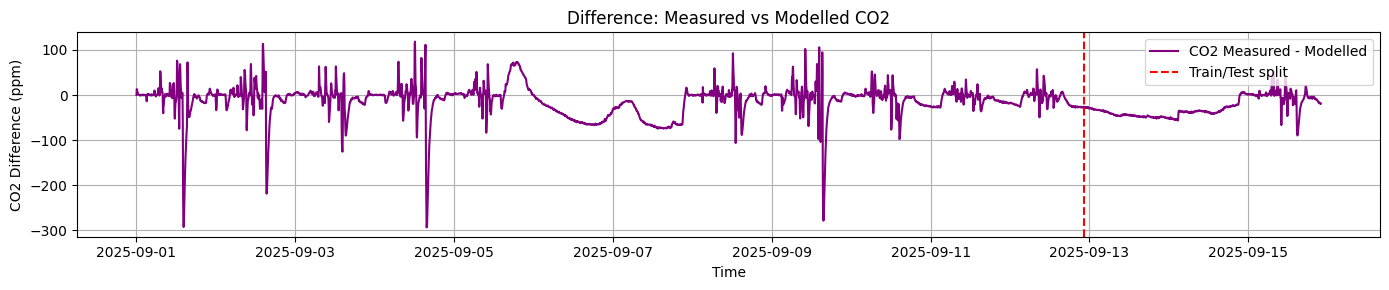

In [ ]:
# Helper function to safely extract variables from results
def get_var(result, key, default=0):
    return result.var[key] if key in result.var else np.zeros(len(result.var[list(result.var.keys())[0]]))

# Extract Q_int, Q_vent, Q_solar, and N from train and test results
Q_int_train = get_var(train_results, 'Q_int')
Q_vent_train = get_var(train_results, 'Q_vent')
Q_solar_train = get_var(train_results, 'Q_solar')
N_train = get_var(train_results, 'N')

Q_int_test = get_var(test_results, 'Q_int')
Q_vent_test = get_var(test_results, 'Q_vent')
Q_solar_test = get_var(test_results, 'Q_solar')
N_test = get_var(test_results, 'N')

# Concatenate train and test for full time series
Q_int_full = np.concatenate([Q_int_train, Q_int_test])
Q_vent_full = np.concatenate([Q_vent_train, Q_vent_test])
Q_solar_full = np.concatenate([Q_solar_train, Q_solar_test])
N_full = np.concatenate([N_train, N_test])

# Get full index from y_train and y_test
full_index = pd.Index(list(y_train.index) + list(y_test.index))

# Plot heat gains
fig1, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(full_index, Q_int_full, label='Q_int (Internal Gains)')
ax1.plot(full_index, Q_vent_full, label='Q_vent (Ventilation Gains)')
ax1.plot(full_index, Q_solar_full, label='Q_solar (Solar Gains)')
ax1.axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
ax1.set_xlabel('Time')
ax1.set_ylabel('Power (W)')
ax1.set_title('Model Heat Gains')
ax1.legend(loc='upper left')
ax1.grid(True)
plt.tight_layout()
plt.show()

# Plot N (occupancy) separately
fig2, ax2 = plt.subplots(figsize=(14, 3))
ax2.plot(full_index, N_full, color='black', label='N (Occupancy)', linewidth=1.5, alpha=0.7)
ax2.axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
ax2.set_xlabel('Time')
ax2.set_ylabel('Occupancy (Number of People)')
ax2.set_title('Model Occupancy (N)')
ax2.legend(loc='upper right')
ax2.grid(True)
plt.tight_layout()
plt.show()


# Plot the difference between measured CO2 (c) and modelled CO2, along with N
# Extract measured and modelled CO2 concentrations
c_measured = pd.concat([input_df.loc[y_train.index, 'c'], input_df.loc[y_test.index, 'c']])
c_modelled = np.concatenate([get_var(train_results, 'c'), get_var(test_results, 'c')])

# Plot measured vs modelled CO2 and N
fig3, ax3 = plt.subplots(figsize=(14, 6))
ax3.plot(full_index, c_measured, label='CO2 Measured', color='blue')
ax3.plot(full_index, c_modelled, label='CO2 Modelled', color='orange', alpha=0.7)
ax3.axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
ax3.set_xlabel('Time')
ax3.set_ylabel('CO2 Concentration (ppm)')
ax3.set_title('Measured vs Modelled CO2 Concentration')
ax3.legend(loc='upper left')
ax3.grid(True)

# Add a secondary axis for N
ax4 = ax3.twinx()
ax4.plot(full_index, N_full, label='N (Occupancy)', color='green', linestyle='--', alpha=0.5)
ax4.set_ylabel('Occupancy (Number of People)')
ax4.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Plot the difference between measured and modelled CO2
fig4, ax5 = plt.subplots(figsize=(14, 3))
co2_diff = c_measured.values - c_modelled
ax5.plot(full_index, co2_diff, label='CO2 Measured - Modelled', color='purple')
ax5.axvline(x=y_train.index[-1], color='r', linestyle='--', label='Train/Test split')
ax5.set_xlabel('Time')
ax5.set_ylabel('CO2 Difference (ppm)')
ax5.set_title('Difference: Measured vs Modelled CO2')
ax5.legend(loc='upper right')
ax5.grid(True)
plt.tight_layout()
plt.show()

New results

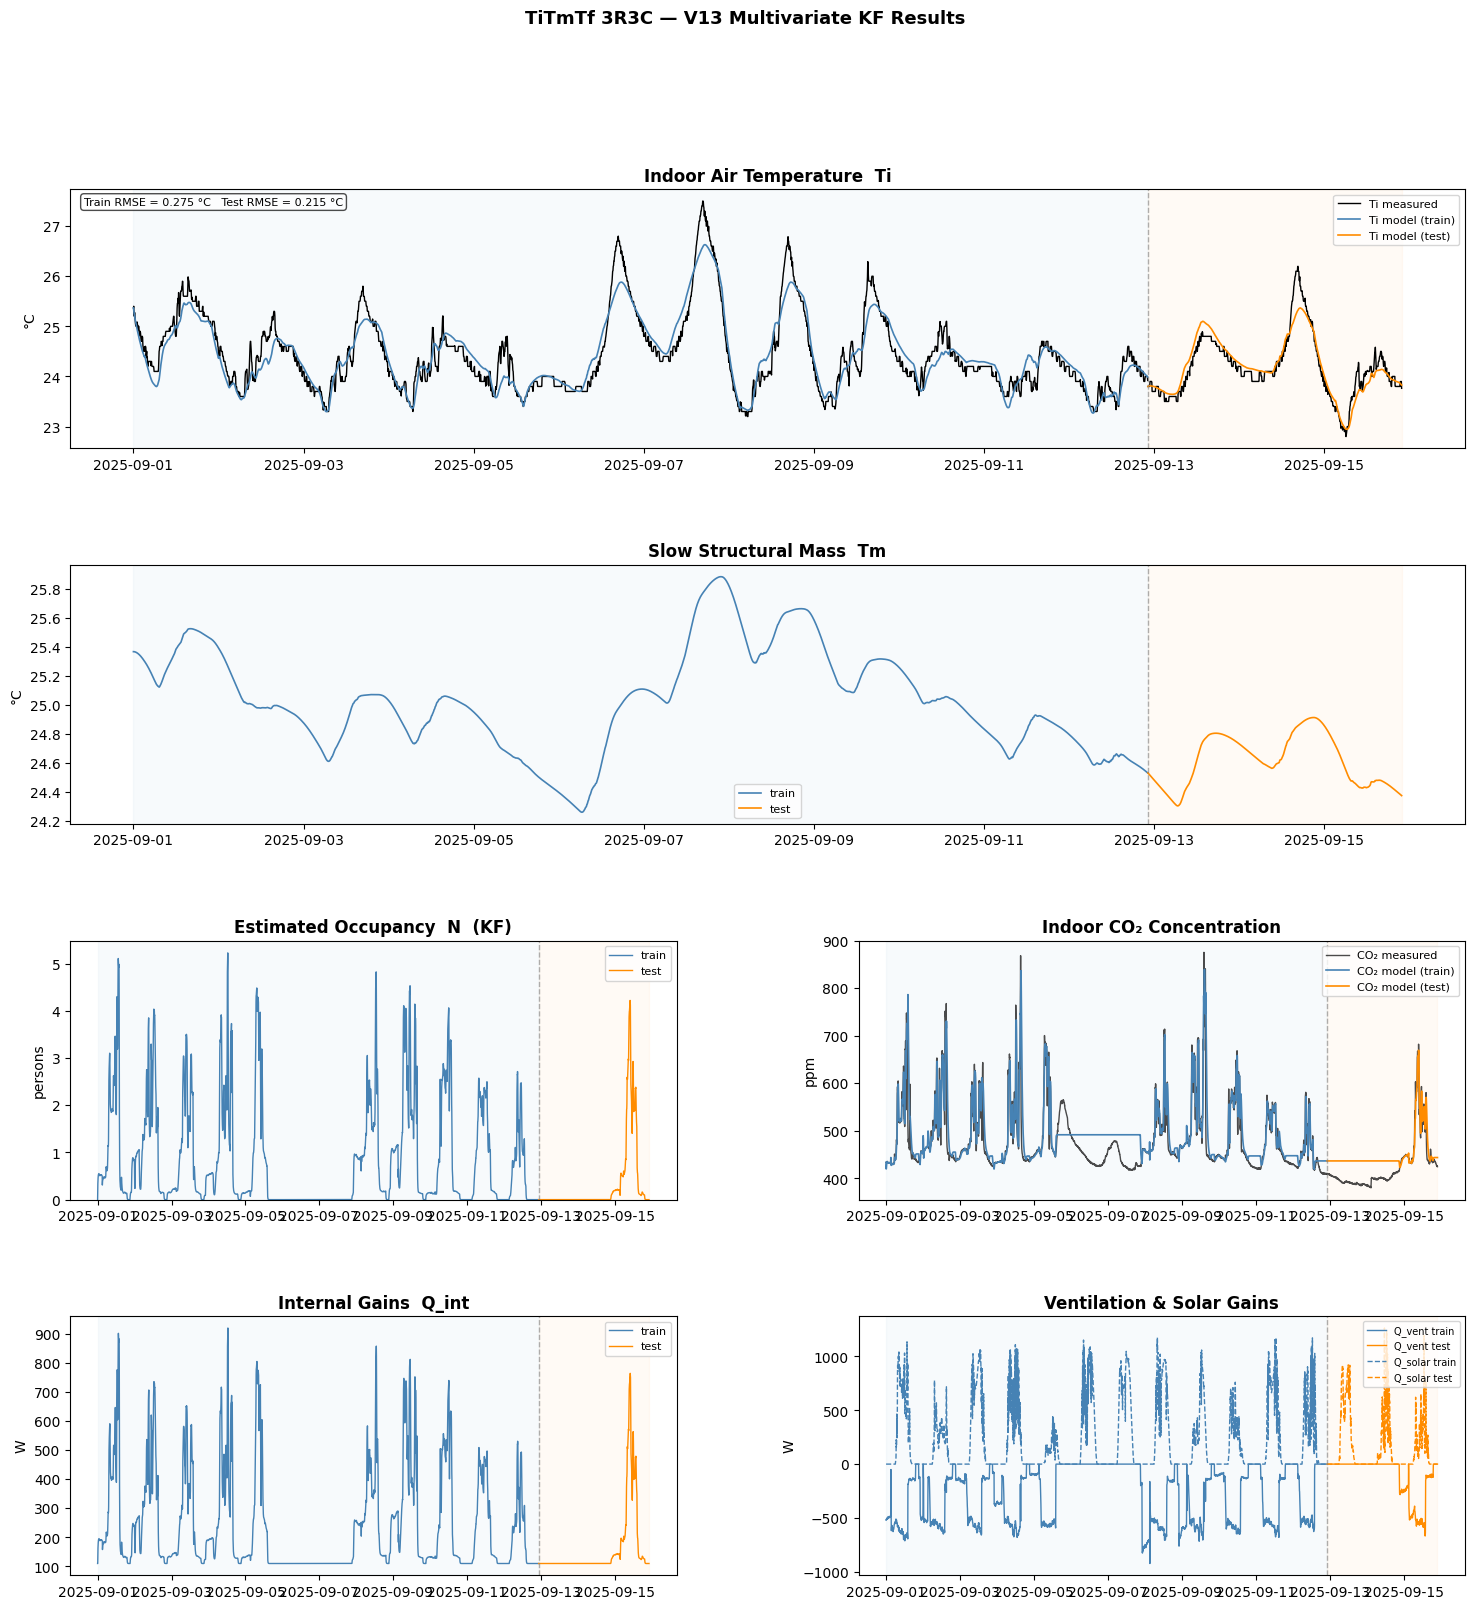

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Reconstruct time index ────────────────────────────────────────────────────
train_index = X_train.index
test_index  = X_test.index

# ── Unpack results ────────────────────────────────────────────────────────────
Ti_train   = get_var(train_results, 'Ti')
Tm_train   = get_var(train_results, 'Tm')
N_train    = get_var(train_results, 'N')
c_train    = get_var(train_results, 'c')
Qint_train = get_var(train_results, 'Q_int')
Qven_train = get_var(train_results, 'Q_vent')
Qsol_train = get_var(train_results, 'Q_solar')

Ti_test    = get_var(test_results, 'Ti')
Tm_test    = get_var(test_results, 'Tm')
N_test     = get_var(test_results, 'N')
c_test     = get_var(test_results, 'c')
Qint_test  = get_var(test_results, 'Q_int')
Qven_test  = get_var(test_results, 'Q_vent')
Qsol_test  = get_var(test_results, 'Q_solar')

c_meas_train = np.asarray(X_train['c'], dtype=float)
c_meas_test  = np.asarray(X_test['c'],  dtype=float)

# ── Figure layout — 4 rows, no innovation panel ───────────────────────────────
fig = plt.figure(figsize=(18, 18))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)

ax_ti   = fig.add_subplot(gs[0, :])
ax_tm   = fig.add_subplot(gs[1, :])
ax_n    = fig.add_subplot(gs[2, 0])
ax_co2  = fig.add_subplot(gs[2, 1])
ax_qint = fig.add_subplot(gs[3, 0])
ax_qven = fig.add_subplot(gs[3, 1])

# ── Helper ────────────────────────────────────────────────────────────────────
def shade_split(ax):
    ax.axvline(test_index[0], color='grey', lw=1, ls='--', alpha=0.6)
    ax.axvspan(train_index[0], test_index[0],  alpha=0.04, color='steelblue')
    ax.axvspan(test_index[0],  test_index[-1], alpha=0.04, color='darkorange')

# ── 1. Ti ─────────────────────────────────────────────────────────────────────
ax_ti.plot(train_index, y_train,  color='black',      lw=1.0, label='Ti measured')
ax_ti.plot(train_index, Ti_train, color='steelblue',  lw=1.2, label='Ti model (train)')
ax_ti.plot(test_index,  y_test,   color='black',      lw=1.0)
ax_ti.plot(test_index,  Ti_test,  color='darkorange', lw=1.2, label='Ti model (test)')
shade_split(ax_ti)
ax_ti.set_title('Indoor Air Temperature  Ti', fontweight='bold')
ax_ti.set_ylabel('°C')
ax_ti.legend(fontsize=8)
ax_ti.text(0.01, 0.97,
    f'Train RMSE = {rmse(Ti_train, y_train.values):.3f} °C   '
    f'Test RMSE = {rmse(Ti_test, y_test.values):.3f} °C',
    transform=ax_ti.transAxes, va='top', fontsize=8,
    bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# ── 2. Tm — full width ────────────────────────────────────────────────────────
ax_tm.plot(train_index, Tm_train, color='steelblue',  lw=1.2, label='train')
ax_tm.plot(test_index,  Tm_test,  color='darkorange', lw=1.2, label='test')
shade_split(ax_tm)
ax_tm.set_title('Slow Structural Mass  Tm', fontweight='bold')
ax_tm.set_ylabel('°C')
ax_tm.legend(fontsize=8)

# ── 3. Occupancy N ────────────────────────────────────────────────────────────
ax_n.plot(train_index, N_train, color='steelblue',  lw=1.0, label='train')
ax_n.plot(test_index,  N_test,  color='darkorange', lw=1.0, label='test')
ax_n.set_ylim(bottom=0)
shade_split(ax_n)
ax_n.set_title('Estimated Occupancy  N  (KF)', fontweight='bold')
ax_n.set_ylabel('persons')
ax_n.legend(fontsize=8)

# ── 4. CO2 ────────────────────────────────────────────────────────────────────
ax_co2.plot(train_index, c_meas_train, color='black',      lw=1.0, alpha=0.7, label='CO₂ measured')
ax_co2.plot(train_index, c_train,      color='steelblue',  lw=1.2, label='CO₂ model (train)')
ax_co2.plot(test_index,  c_meas_test,  color='black',      lw=1.0, alpha=0.7)
ax_co2.plot(test_index,  c_test,       color='darkorange', lw=1.2, label='CO₂ model (test)')
shade_split(ax_co2)
ax_co2.set_title('Indoor CO₂ Concentration', fontweight='bold')
ax_co2.set_ylabel('ppm')
ax_co2.legend(fontsize=8)

# ── 5. Internal heat gains ────────────────────────────────────────────────────
ax_qint.plot(train_index, Qint_train, color='steelblue',  lw=1.0, label='train')
ax_qint.plot(test_index,  Qint_test,  color='darkorange', lw=1.0, label='test')
shade_split(ax_qint)
ax_qint.set_title('Internal Gains  Q_int', fontweight='bold')
ax_qint.set_ylabel('W')
ax_qint.legend(fontsize=8)

# ── 6. Ventilation + solar ────────────────────────────────────────────────────
ax_qven.plot(train_index, Qven_train, color='steelblue',  lw=1.0, label='Q_vent train')
ax_qven.plot(test_index,  Qven_test,  color='darkorange', lw=1.0, label='Q_vent test')
ax_qven.plot(train_index, Qsol_train, color='steelblue',  lw=1.0, ls='--', label='Q_solar train')
ax_qven.plot(test_index,  Qsol_test,  color='darkorange', lw=1.0, ls='--', label='Q_solar test')
shade_split(ax_qven)
ax_qven.set_title('Ventilation & Solar Gains', fontweight='bold')
ax_qven.set_ylabel('W')
ax_qven.legend(fontsize=7)

# ── Save ──────────────────────────────────────────────────────────────────────
fig.suptitle('TiTmTf 3R3C — V13 Multivariate KF Results',
             fontsize=13, fontweight='bold')
plt.savefig('V13_results.png', dpi=150, bbox_inches='tight')
plt.show()
